In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import NamedTuple

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.coords import pos2shift
from bloodmoon.mask import CodedMaskCamera, codedmask, count, decode
from bloodmoon.optim import model_shadowgram, model_sky

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.optim import bkg_smoothing
from darksun.show import slices_plot

from var import sky_variance, sky_significance


class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float


def find_candidate(
    sky: NDArray,
    snr: NDArray,
    threshold: int | float,
    batch: int = 1000,
) -> tuple:
    """Returns candidate."""
    reservoir = np.array(
        [np.unravel_index(id, sky.shape) for id in np.argsort(sky, axis=None)[-batch:]]
    )
    for pos in reservoir[::-1]:
        if (snr[*pos] > threshold):
            return tuple(pos)
    return tuple()


def retrieve_sky(
    candidates: tuple[Candidate],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Generates detector image from retrieved candidates."""
    img = np.zeros(camera.shape_sky)
    for (sx, sy, f, _) in candidates:
        sky = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        )
        img += sky
    return img

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


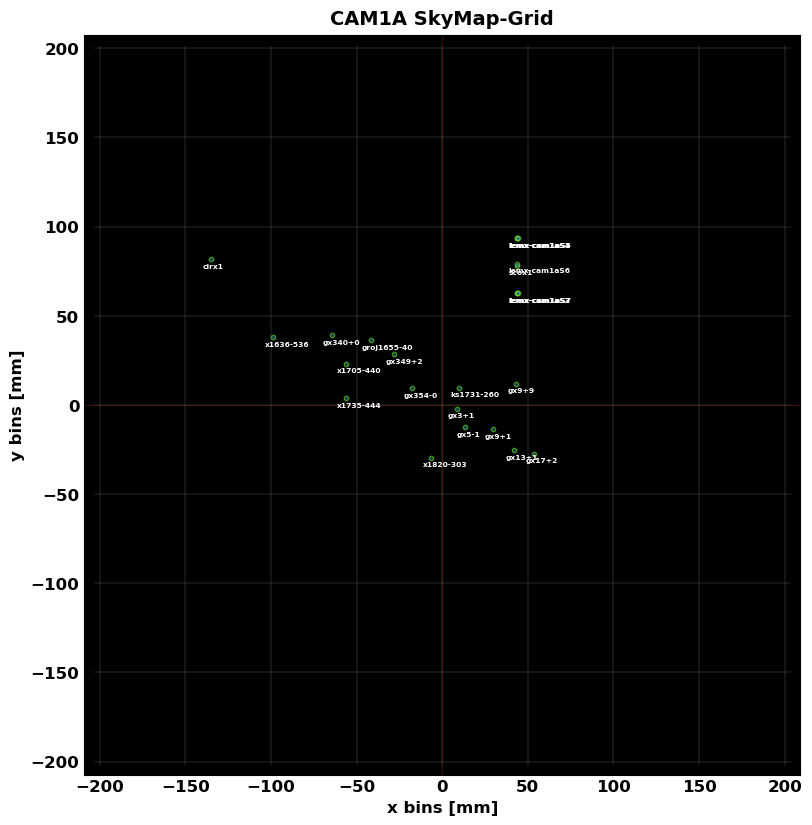

,CAM1A,CAM1A SNR,CAM1A SX,CAM1A SY
0,scox1,840.337549,43.909382,78.035210
1,gx5-1,82.431910,13.525754,-12.484223
2,gx349+2,60.525373,-28.163651,28.682183
3,gx17+2,49.136696,53.589958,-27.325576
4,gx9+1,48.724677,29.853928,-13.406802
5,gx340+0,31.343038,-64.635569,39.035990
6,gx3+1,27.730317,8.417916,-2.042753
7,gx13+1,27.046338,41.884629,-25.279403
8,x1820-303,22.508100,-6.267464,-29.526399
9,gx9+9,21.029870,42.978615,11.906548


In [2]:
skyfield = "GalacticCentre"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing_optimizerNoPeak_2-10keV"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
#cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
#simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, _ = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")


ds.skyfield_map(
    log=log_camA,
    camera=wfm,
)
pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        f"{log_camA.name} SX": log_camA.log['shift_x'],
        f"{log_camA.name} SY": log_camA.log['shift_y'],
    },
)

In [3]:
_UP_TO = 17

candidates = tuple(
    Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
        log_camA.log['shift_x'][:_UP_TO],
        log_camA.log['shift_y'][:_UP_TO],
        log_camA.log['fluence'][:_UP_TO],
        log_camA.log['snr'][:_UP_TO],
    )
)

print(
    f"Selected sources: {len(candidates)}\n"
    f"Last: {log_camA.log['ID'][_UP_TO - 1]}\n"
    f"Following: {log_camA.log['ID'][_UP_TO]}\n"
)

Selected sources: 17
Last: ks1731-260
Following: lemx-cam1aS1



In [4]:
detector = count(wfm, sdlA.DLdata)[0]
varmap = sky_variance(wfm, detector)

# residual detector
retrieved = retrieve_sky(
    candidates=candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
# res_sky = true - IROS(chosen it.)
res_sky = simul_sky_camA - retrieved

In [5]:
def sequential_subtraction(
    sky: NDArray,
    var: NDArray,
    camera: CodedMaskCamera,
    iterations: int,
    threshold: int | float,
    *,
    vignetting: bool = True,
    psfy: bool = True,
) -> tuple[Candidate, ...]:
    """
    Sequential candidates subtraction and analysis.
    """
    def verbose(idx: int, pos: tuple[int, int], cand: Candidate) -> None:
        """Prints out info."""
        print(
            f'Candidate at iteration {idx}\n'
            f'  - Pos (y, x): {pos}\n',
            f'  - Sky-shifts (x, y): {cand.shift_x, cand.shift_y}\n',
            f'  - Fluence: {cand.fluence}\n',
            f'  - Significance: {cand.snr}\n',
        )

    sky_ = sky.copy()
    cands = []
    crp = (
        int(camera.specs['slit_deltay'] * camera.upscale_f.y / camera.specs['mask_deltay'] + 5),
        int(camera.specs['slit_deltax'] * camera.upscale_f.x / camera.specs['mask_deltax'] + 5),
    )

    for it in range(iterations):
        snr = sky_significance(sky_, var)
        pos = find_candidate(sky_, snr, threshold)
        if pos:
            cand = Candidate(*pos2shift(camera, *pos), sky_[*pos], snr[*pos])
            verbose(it, pos, cand)
            cands.append(cand)

            slices_plot(
                sky=sky_,
                pos=pos,
                crp=crp,
                source=f'cand{it} it. {it} PRESub',
                ylabel='counts [ph]',
            )
            sky_ -= model_sky(
                camera=camera,
                shift_x=cand.shift_x,
                shift_y=cand.shift_y,
                fluence=cand.fluence,
                vignetting=vignetting,
                psfy=psfy,
            )
            slices_plot(
                sky=sky_,
                pos=pos,
                crp=crp,
                source=f'cand{it} it. {it} AFTERSub',
                ylabel='counts [ph]',
            )
        else:
            print('No more candidates...')
            break

    return tuple(cands)


from astropy.io.fits.fitsrec import FITS_rec
from bloodmoon.coords import equatorial2shift, angle2shift

def shifts_errors(camera: CodedMaskCamera) -> tuple[float, float]:
    """
    Computes the camera local-frame coords NOMINAL* errors.
    """
    def arcmin2deg(angle: float) -> float:
        """Converts angle from [arcmin] to [deg]."""
        return angle / 60
    
    UPX, UPY = camera.upscale_f
    # camera angular resolution at given upscaling [arcmin]
    dthetax, dthetay = 5.0 / UPX, 60.0 / UPY
    # local-frame sky-shifts errors [mm]
    dsx, dsy = map(
        lambda x: abs(angle2shift(camera, arcmin2deg(x))),
        (dthetax, dthetay),
    )
    return dsx, dsy

def cands_catalogue_comparison(
    candidates: tuple[Candidate, ...],
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[list[str, Candidate], ...]:
    """
    Candidates catalogue comparison.
    """
    def extend_catalogue(rec: FITS_rec) -> FITS_rec:
        """Adds sources local frame angular coords to catalogue."""
        from astropy.io.fits import Column, BinTableHDU
        extended = [
            Column(name=name, format=rec.columns[name].format, array=rec[name])
            for name in rec.names
        ]
        ssx, ssy = zip(
            *tuple(
                equatorial2shift(sdl, camera, ra, dec) for ra, dec in zip(rec['RA'], rec['DEC'])
            )
        )
        shifts = [
            Column(name='SHIFT_X', format='D', array=np.array(ssx)),
            Column(name='SHIFT_Y', format='D', array=np.array(ssy)),
        ]
        return BinTableHDU.from_columns(extended + shifts).data
    
    # set up
    KEYMAP = {
        'cxb_tag': 'gctr_diffuse',
        'NEW_ID': 1,
    }
    DATABASE = extend_catalogue(catalogue.DLdata)
    CANDS = []

    # catalogue comparison and sources association
    def candidate_association(
        shiftx: float,
        dshiftx: float,
        shifty: float,
        dshifty: float,
        sigma: int | float = 3,
    ) -> str:
        """Candidate association from catalogue."""

        def closest_source(batch: FITS_rec) -> int:
            """Returns candidate's closer catalogue source index."""
            arg = np.argmin(
                np.square(batch['SHIFT_X'] - shiftx) + np.square(batch['SHIFT_Y'] - shifty)
            )
            return arg
    
        box = (
            (DATABASE['SHIFT_X'] > shiftx - sigma * dshiftx) &
            (DATABASE['SHIFT_X'] < shiftx + sigma * dshiftx) &
            (DATABASE['SHIFT_Y'] > shifty - sigma * dshifty) &
            (DATABASE['SHIFT_Y'] < shifty + sigma * dshifty) &
            (DATABASE['ID'] != KEYMAP['cxb_tag'])
        )
        associated_batch = DATABASE[box]

        if not any(associated_batch):
            sourceID = f'lemx-S{KEYMAP['NEW_ID']}'
            KEYMAP['NEW_ID'] += 1
        elif len(associated_batch) == 1:
            sourceID = associated_batch['ID'][0]
        else:
            arg = closest_source(associated_batch)
            sourceID = associated_batch['ID'][arg]

        return sourceID
    
    print("# Comparing with Catalogue...")
    dsx, dsy = shifts_errors(camera)
    # initial sources association
    for cand in candidates:
        sourceID = candidate_association(cand.shift_x, dsx, cand.shift_y, dsy)
        CANDS.append([sourceID, cand])

    print("# Successful comparison!")
    return tuple(CANDS)

Candidate at iteration 0
  - Pos (y, x): (np.int64(570), np.int64(5057))
   - Sky-shifts (x, y): (43.89999999999998, 78.0)
   - Fluence: 19216.54118107108
   - Significance: 14.157575651827035



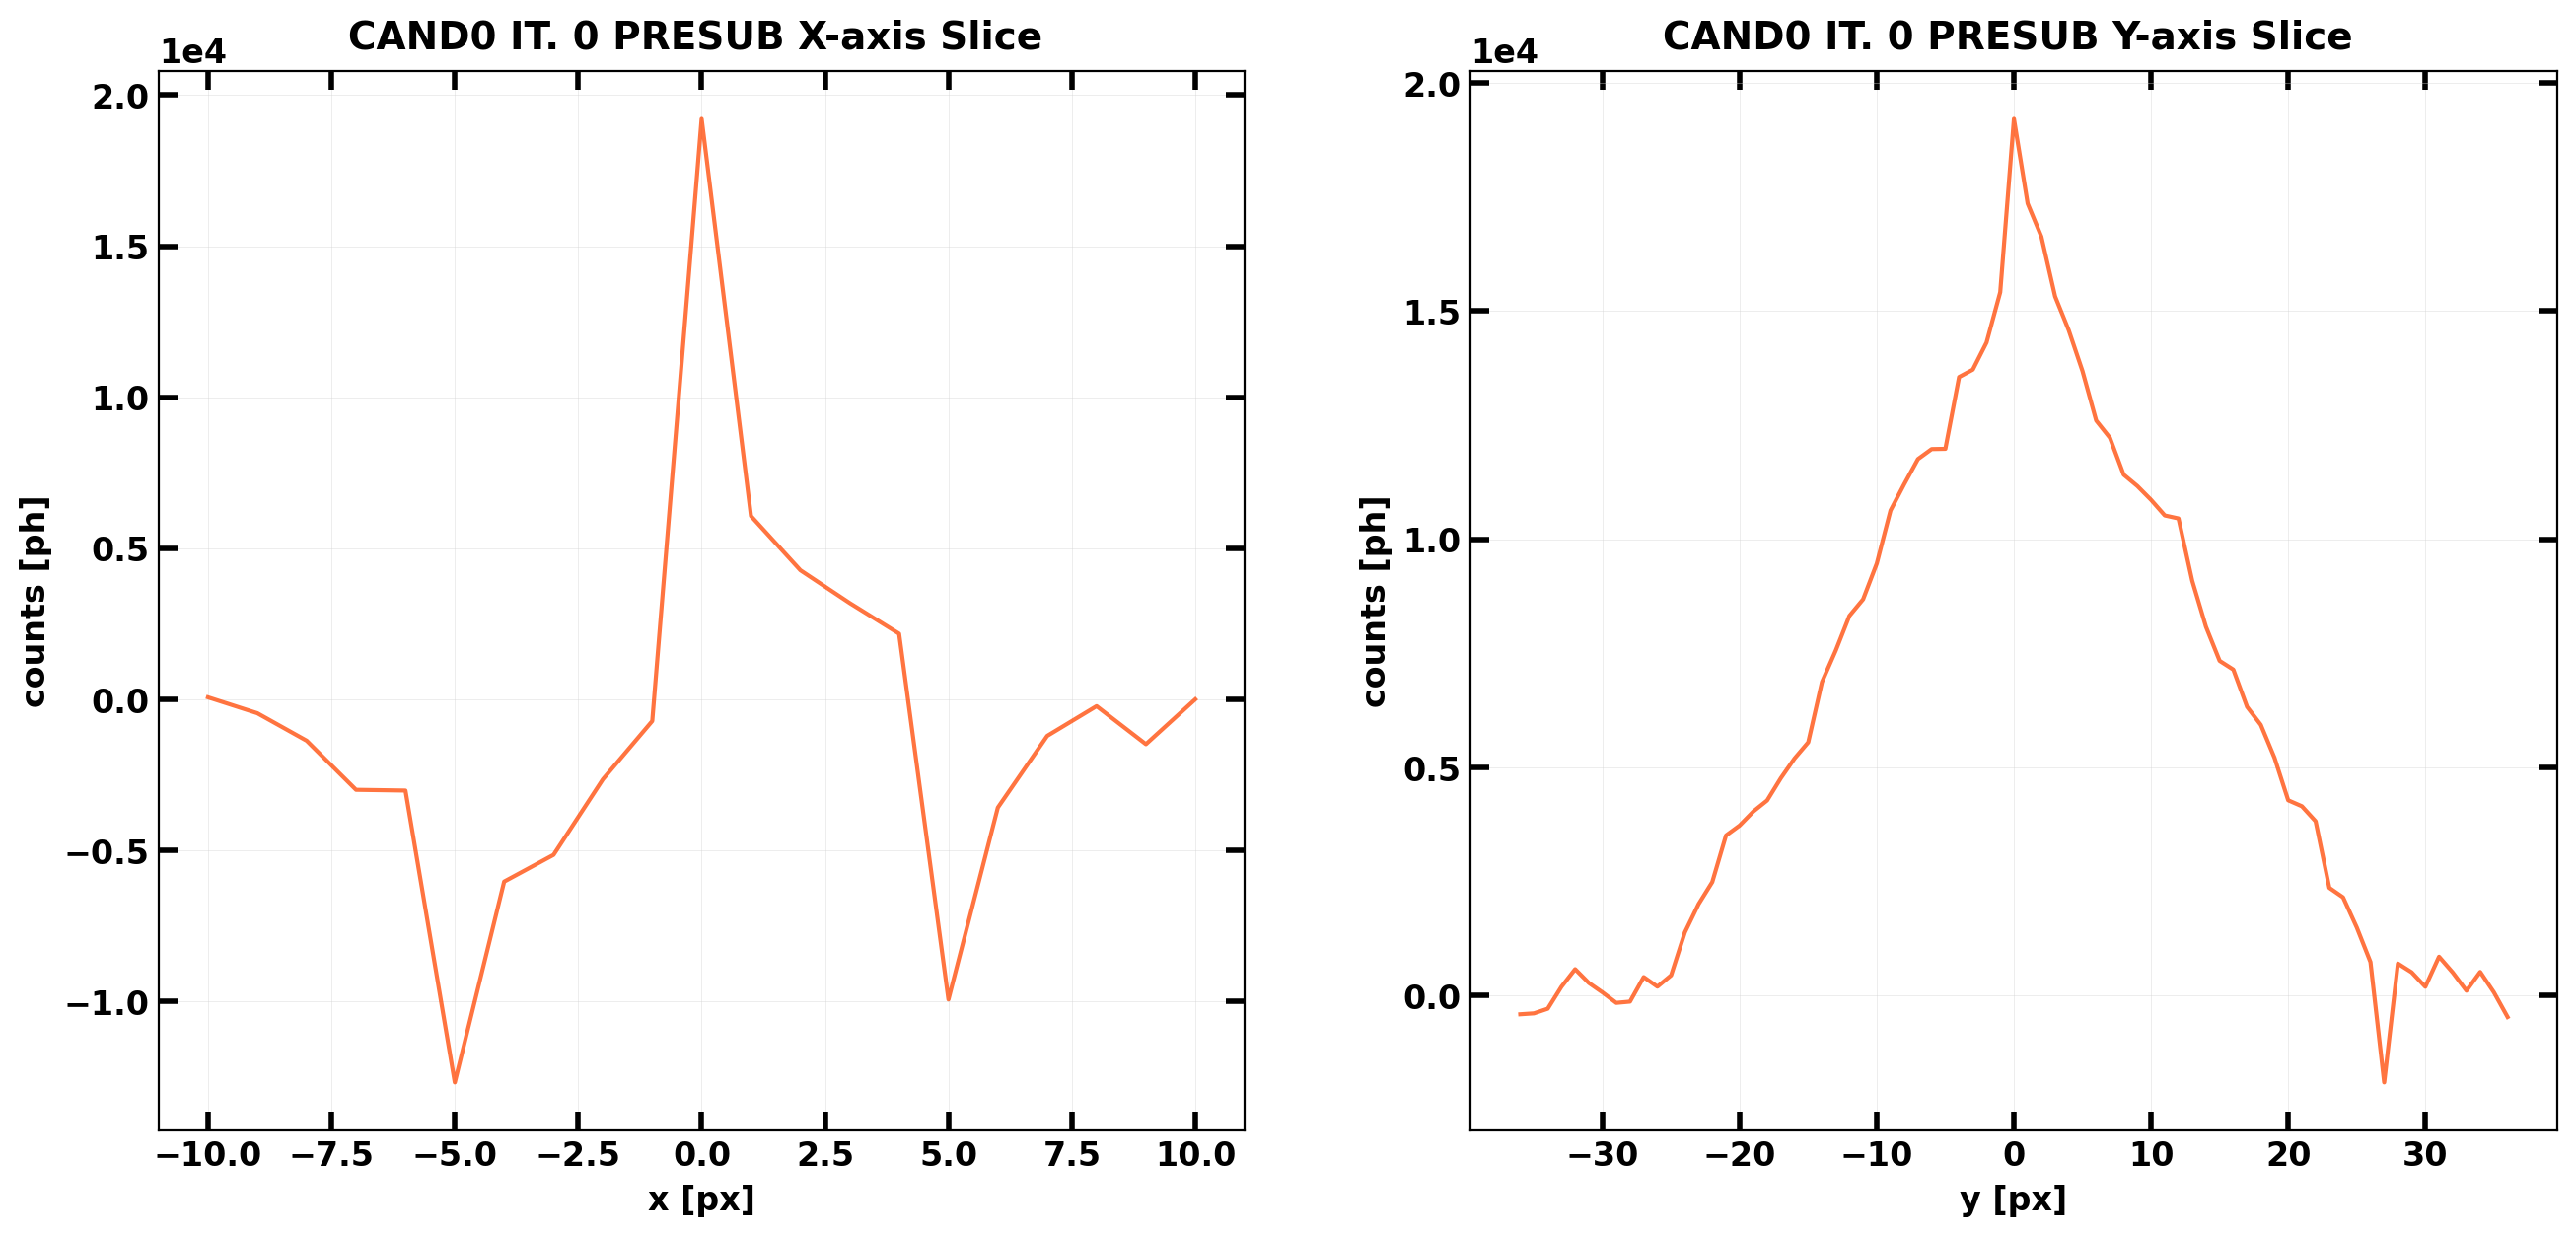

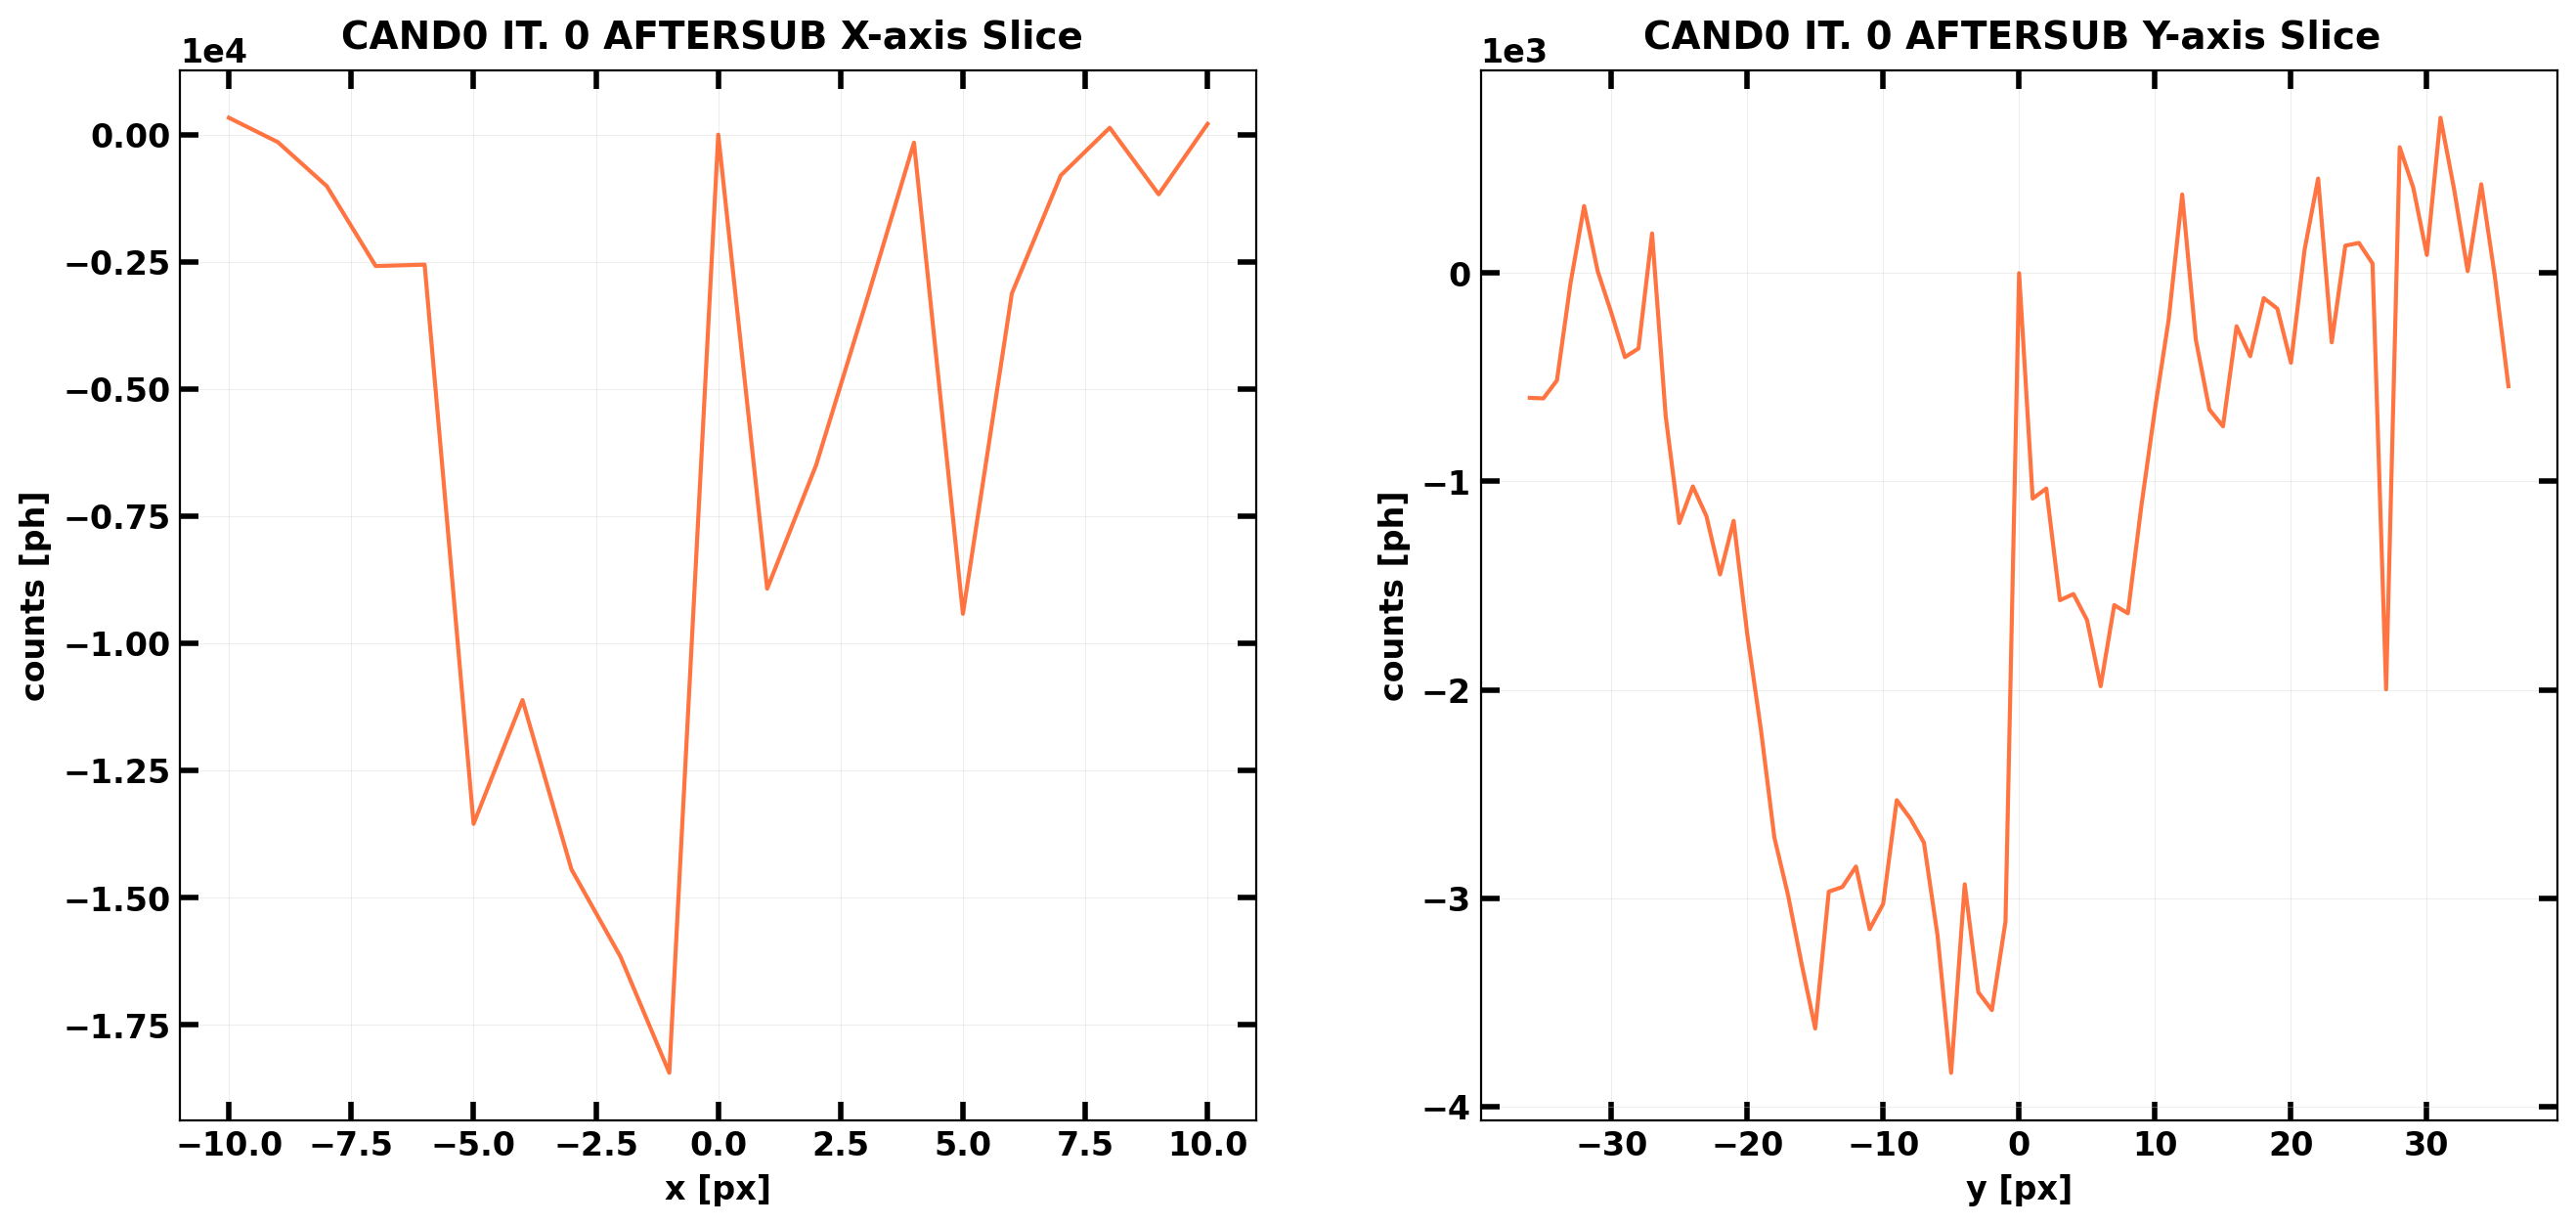

Candidate at iteration 1
  - Pos (y, x): (np.int64(296), np.int64(6929))
   - Sky-shifts (x, y): (137.49999999999997, -59.0)
   - Fluence: 7332.801493610783
   - Significance: 7.021576796637399



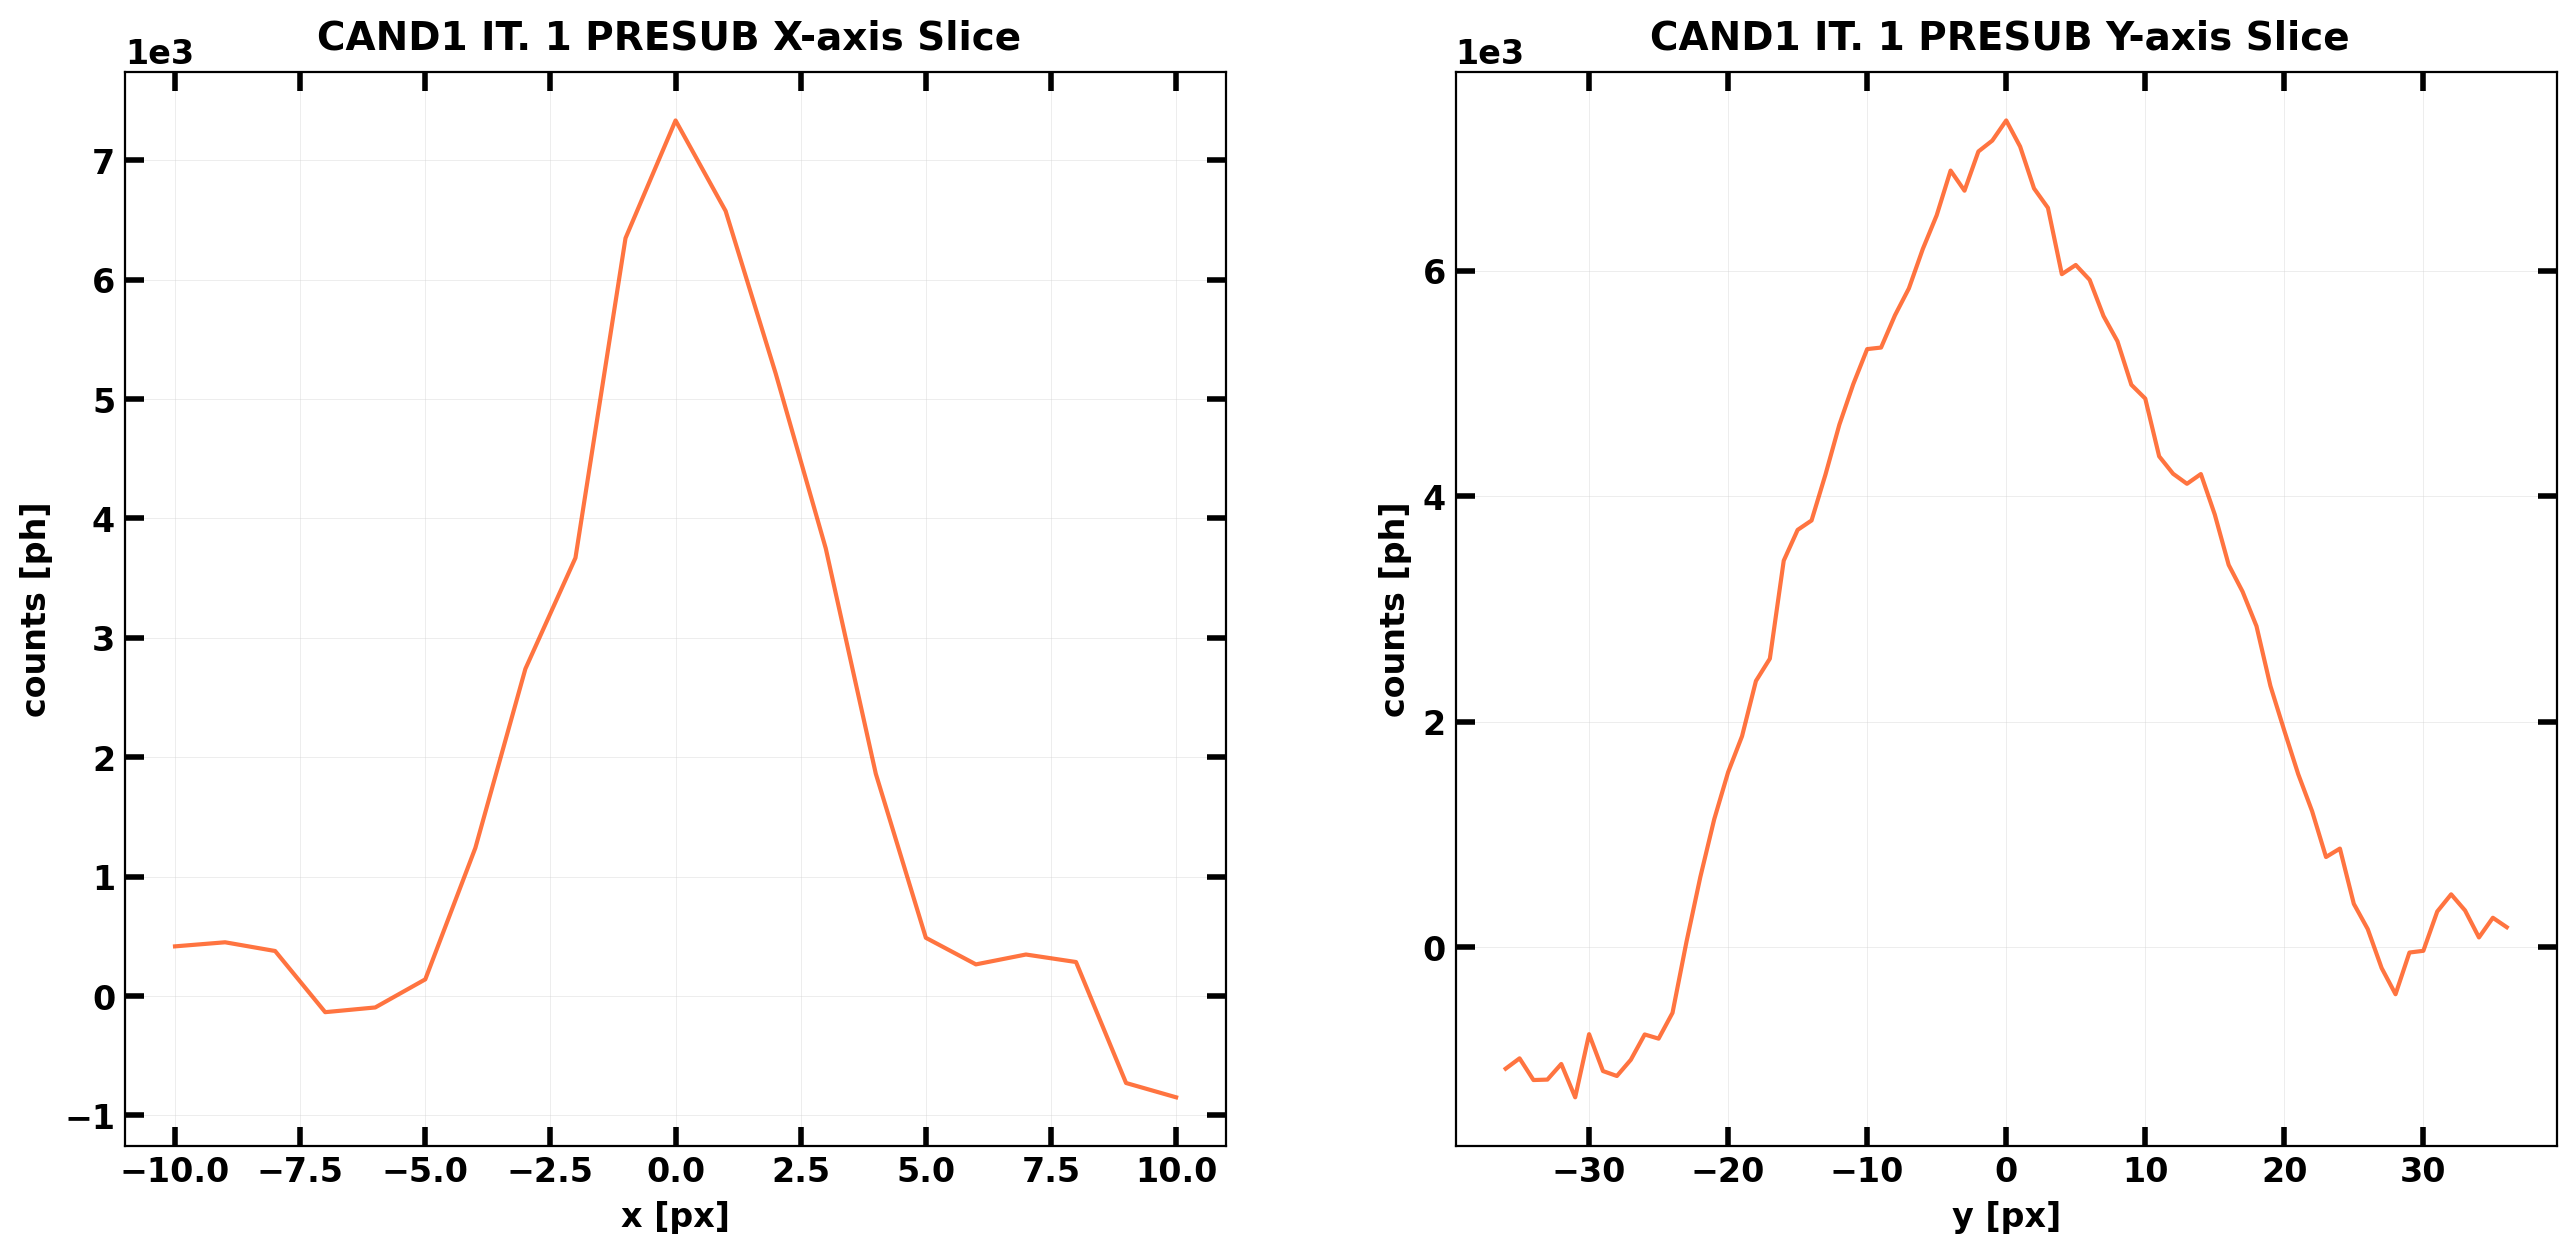

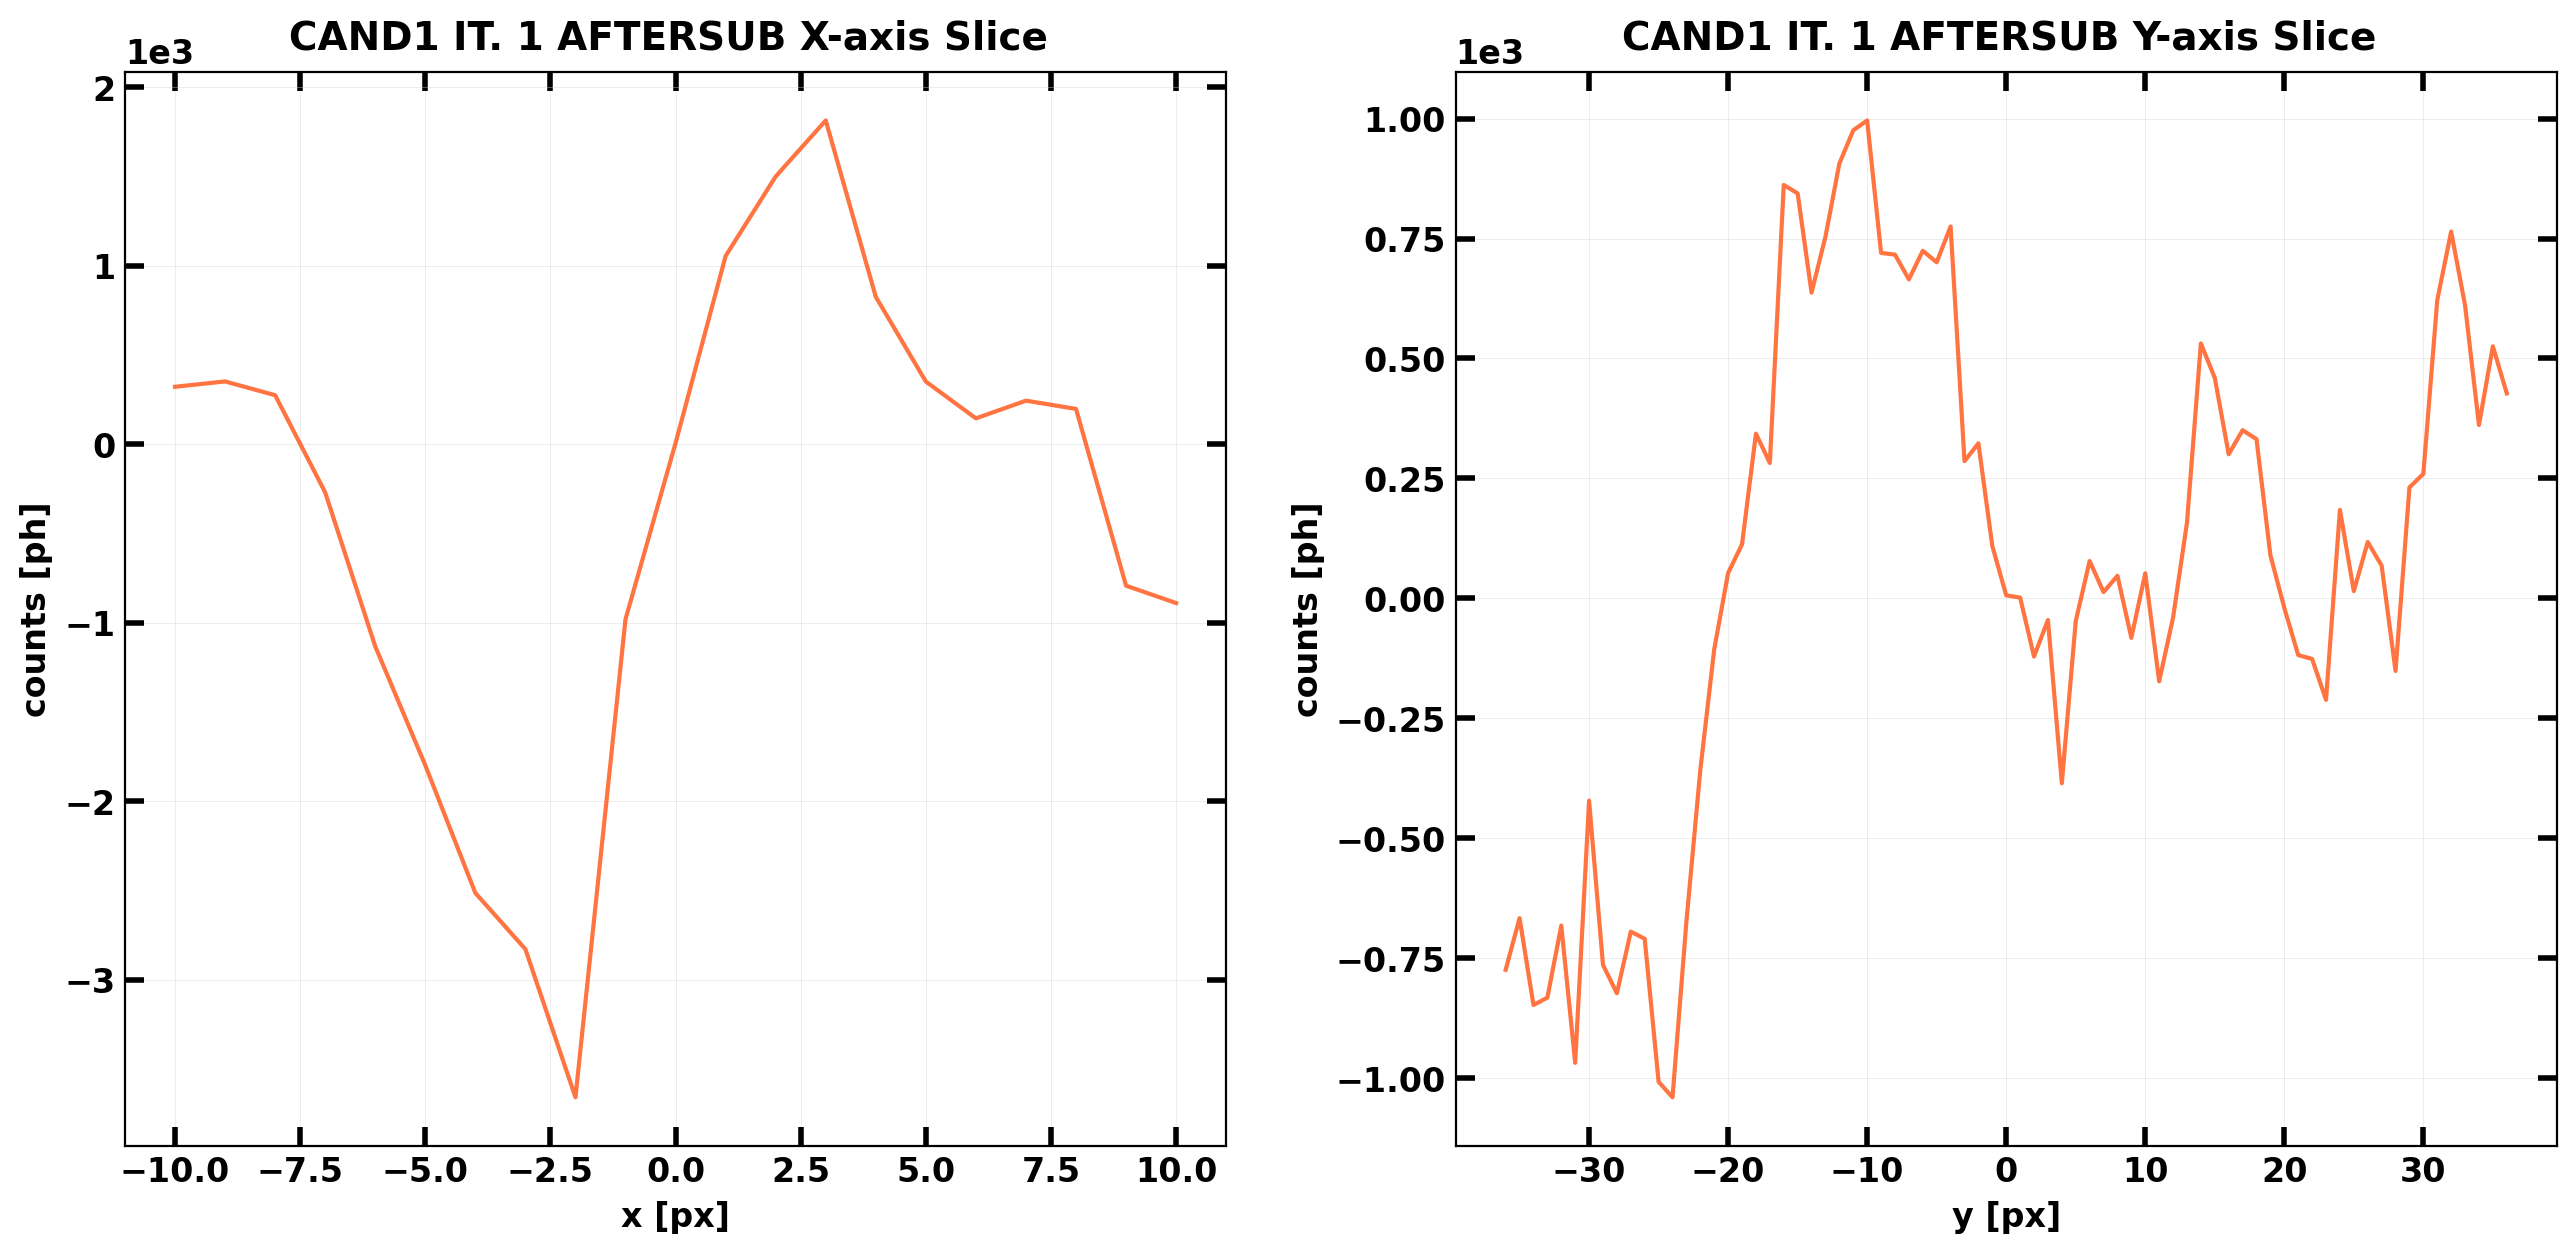

Candidate at iteration 2
  - Pos (y, x): (np.int64(601), np.int64(4784))
   - Sky-shifts (x, y): (30.249999999999986, 93.5)
   - Fluence: 6338.337340364907
   - Significance: 5.018328278239811



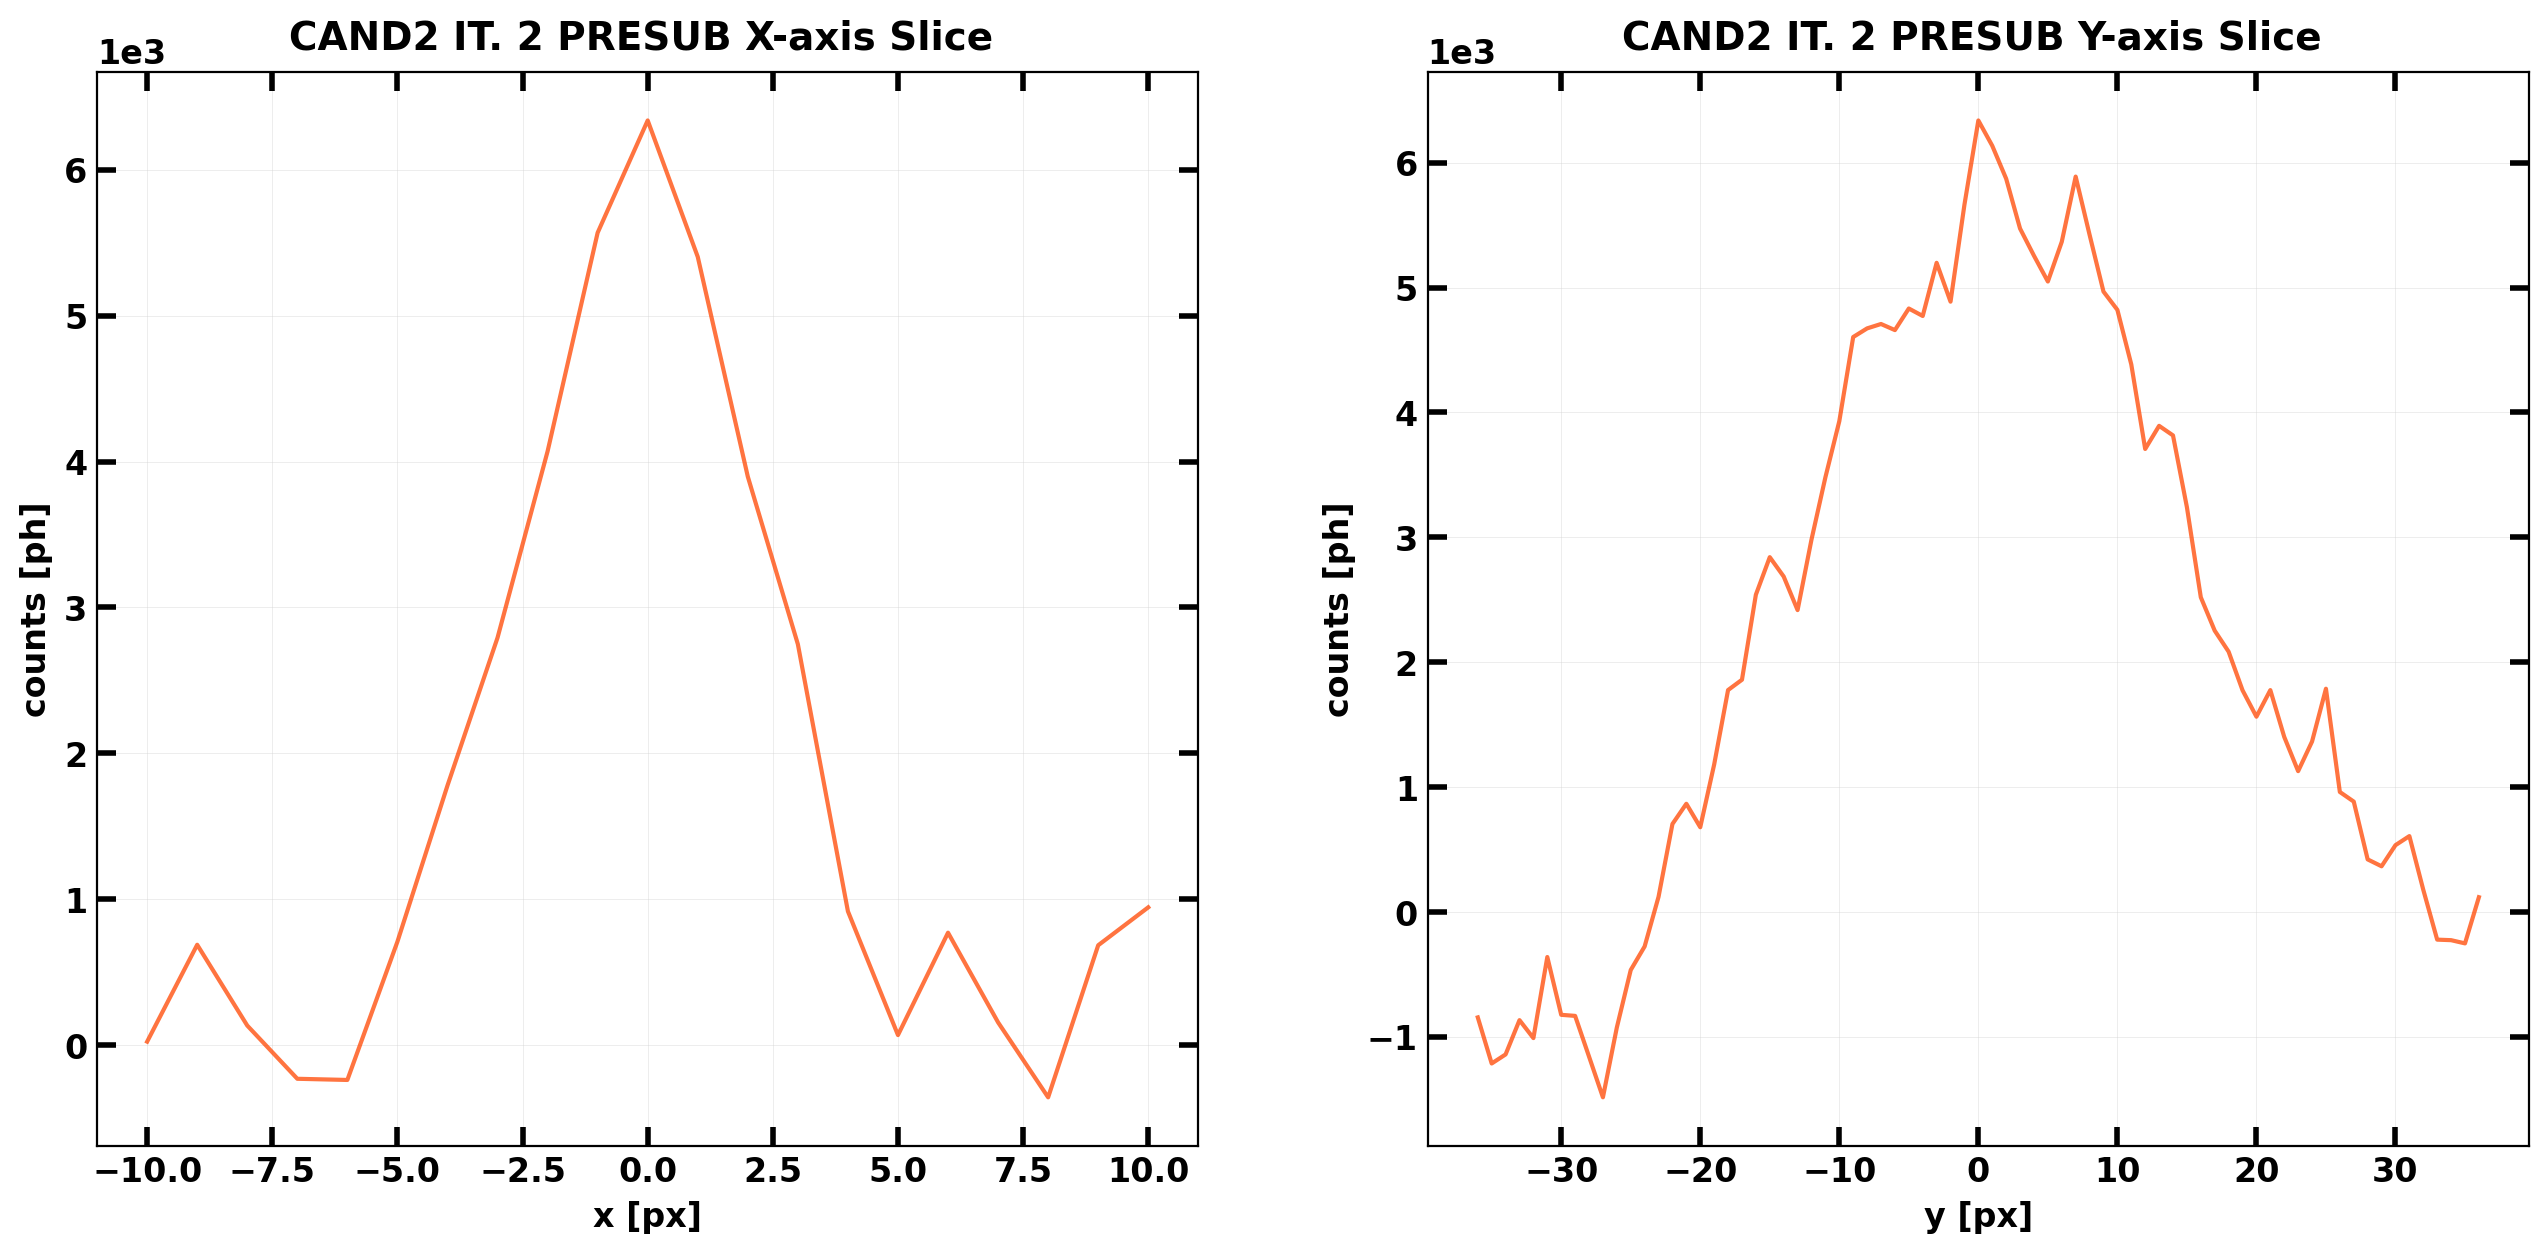

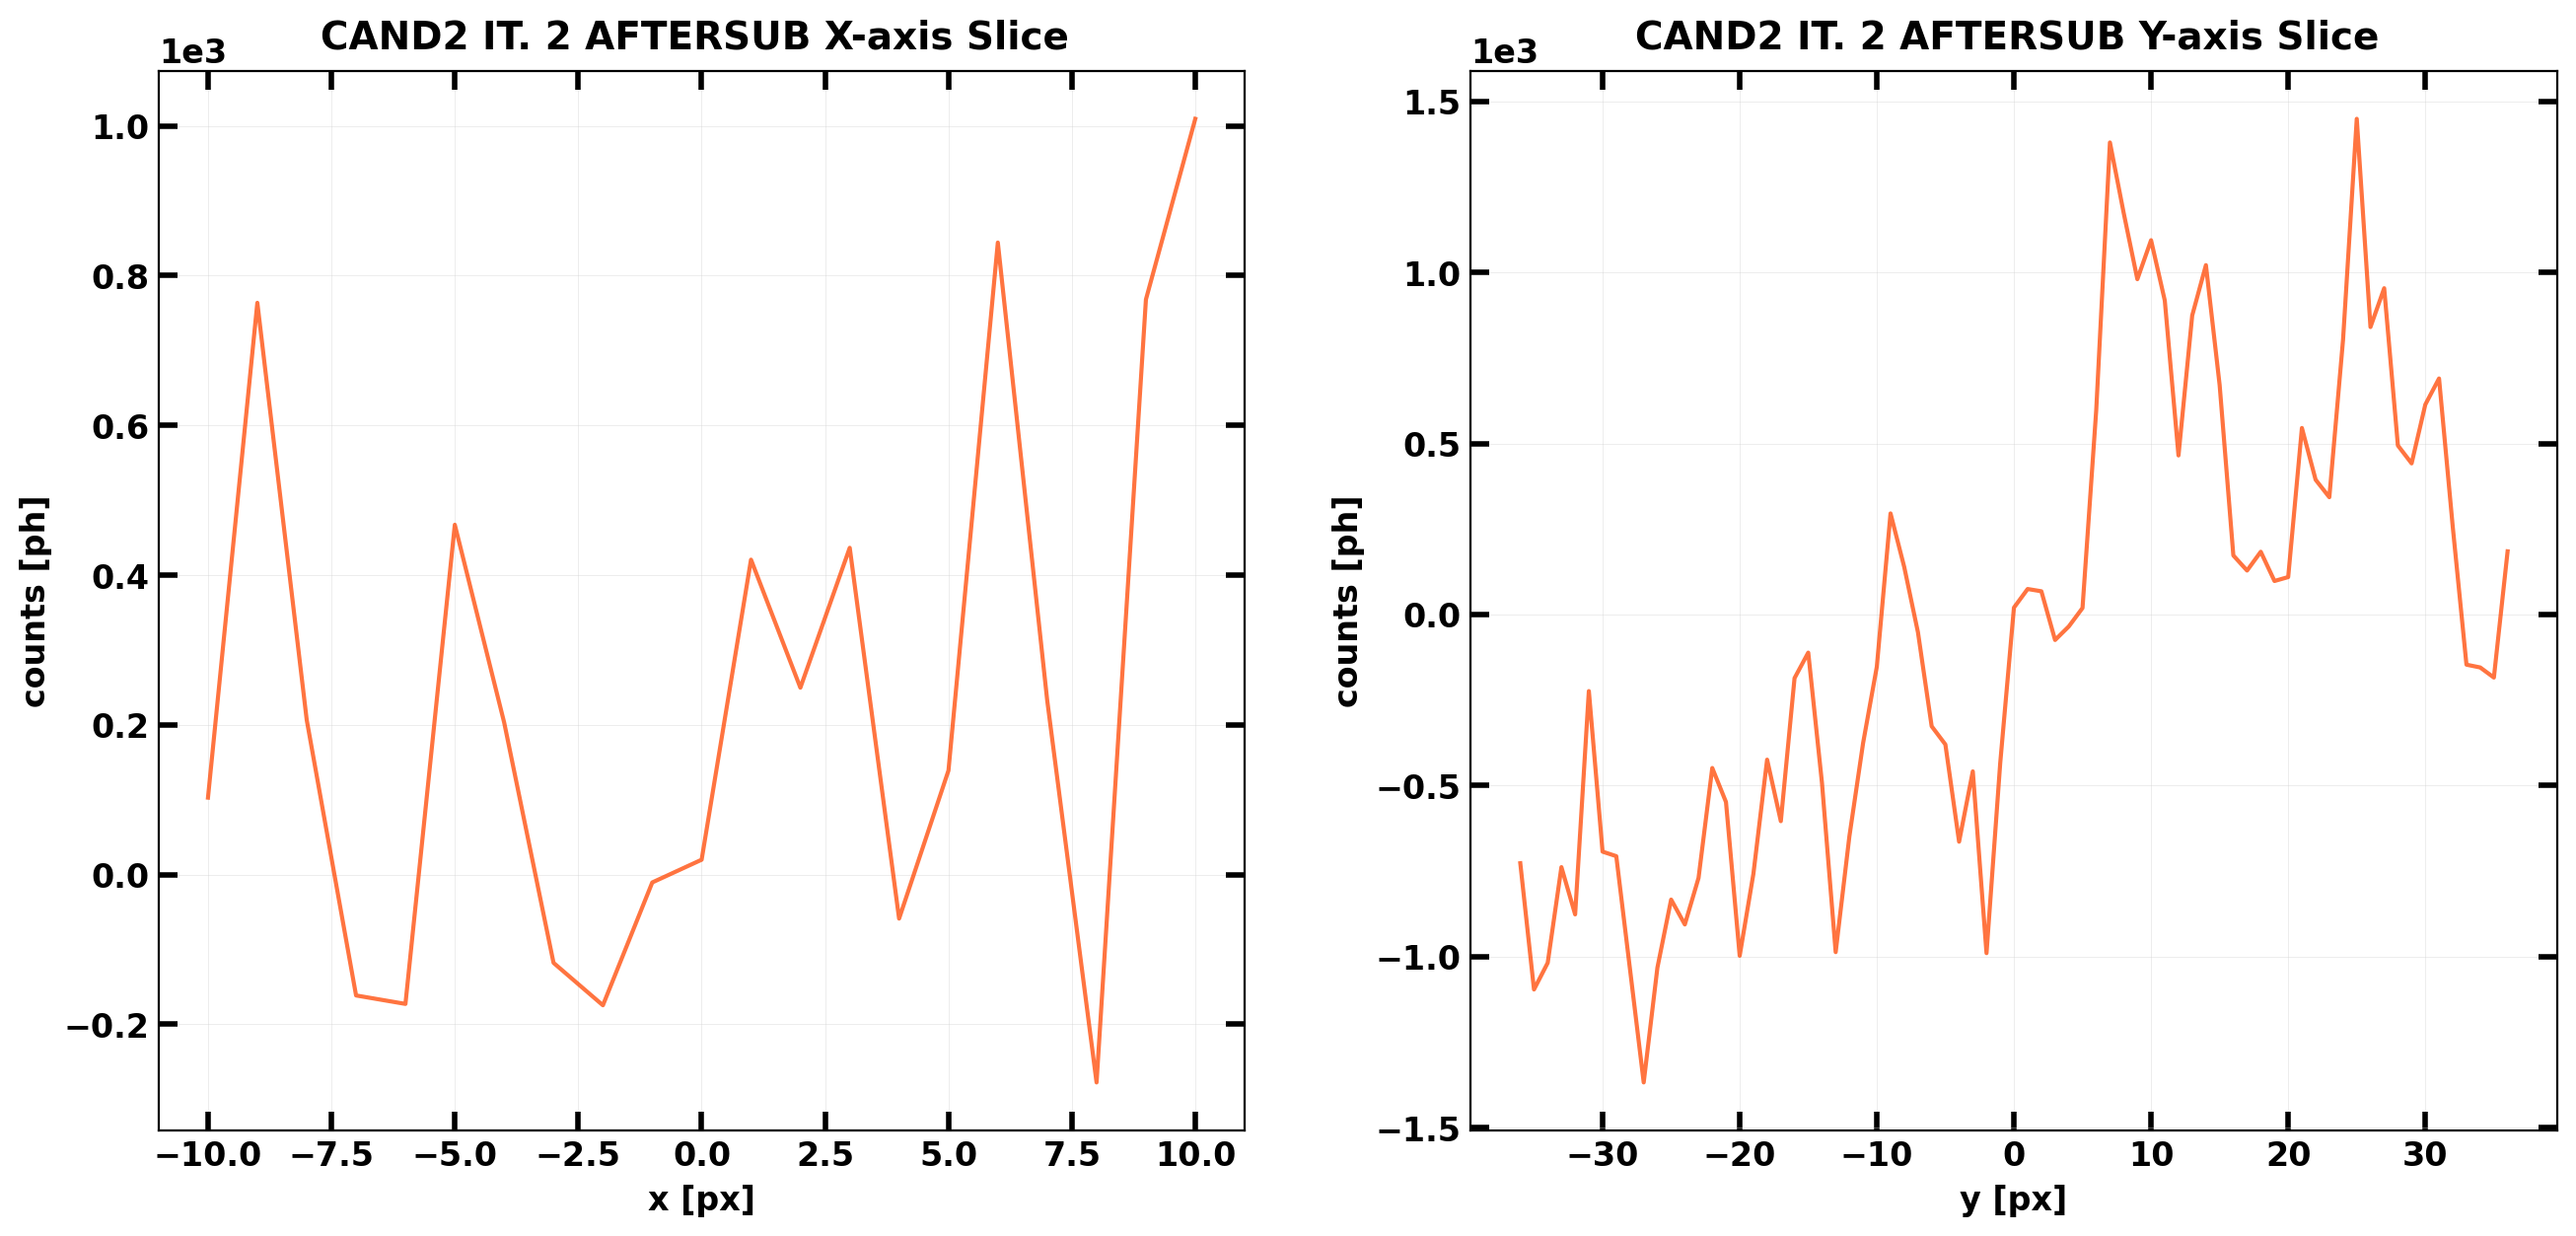

Candidate at iteration 3
  - Pos (y, x): (np.int64(198), np.int64(7678))
   - Sky-shifts (x, y): (174.95, -108.0)
   - Fluence: 5458.892820986468
   - Significance: 9.23793409809087



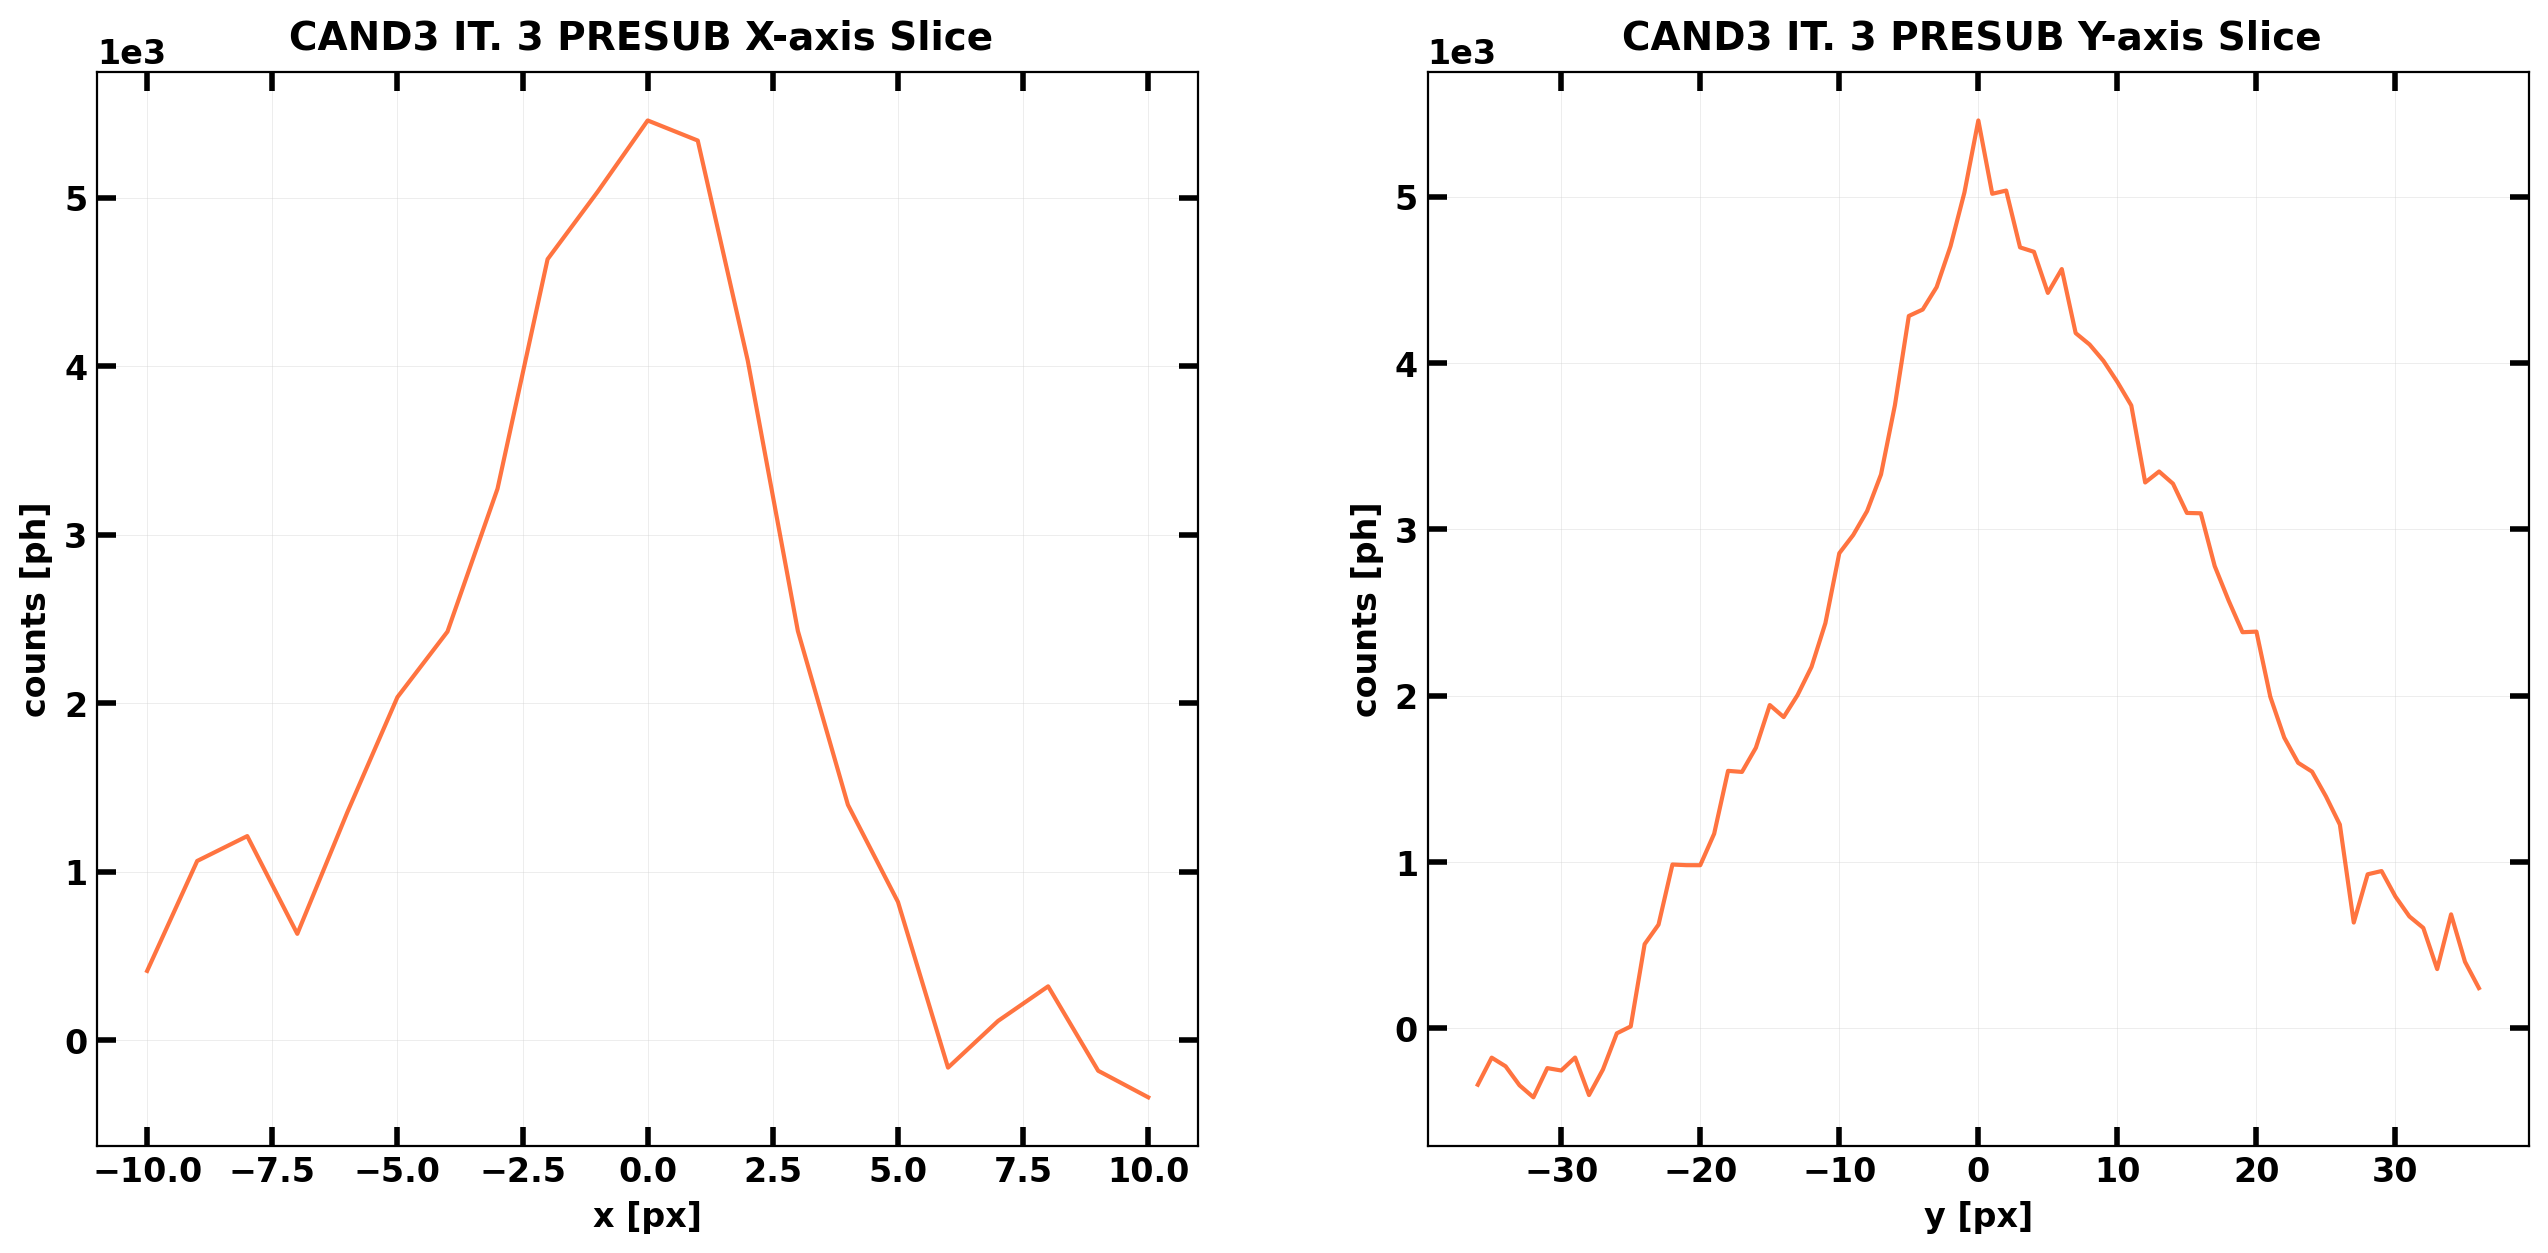

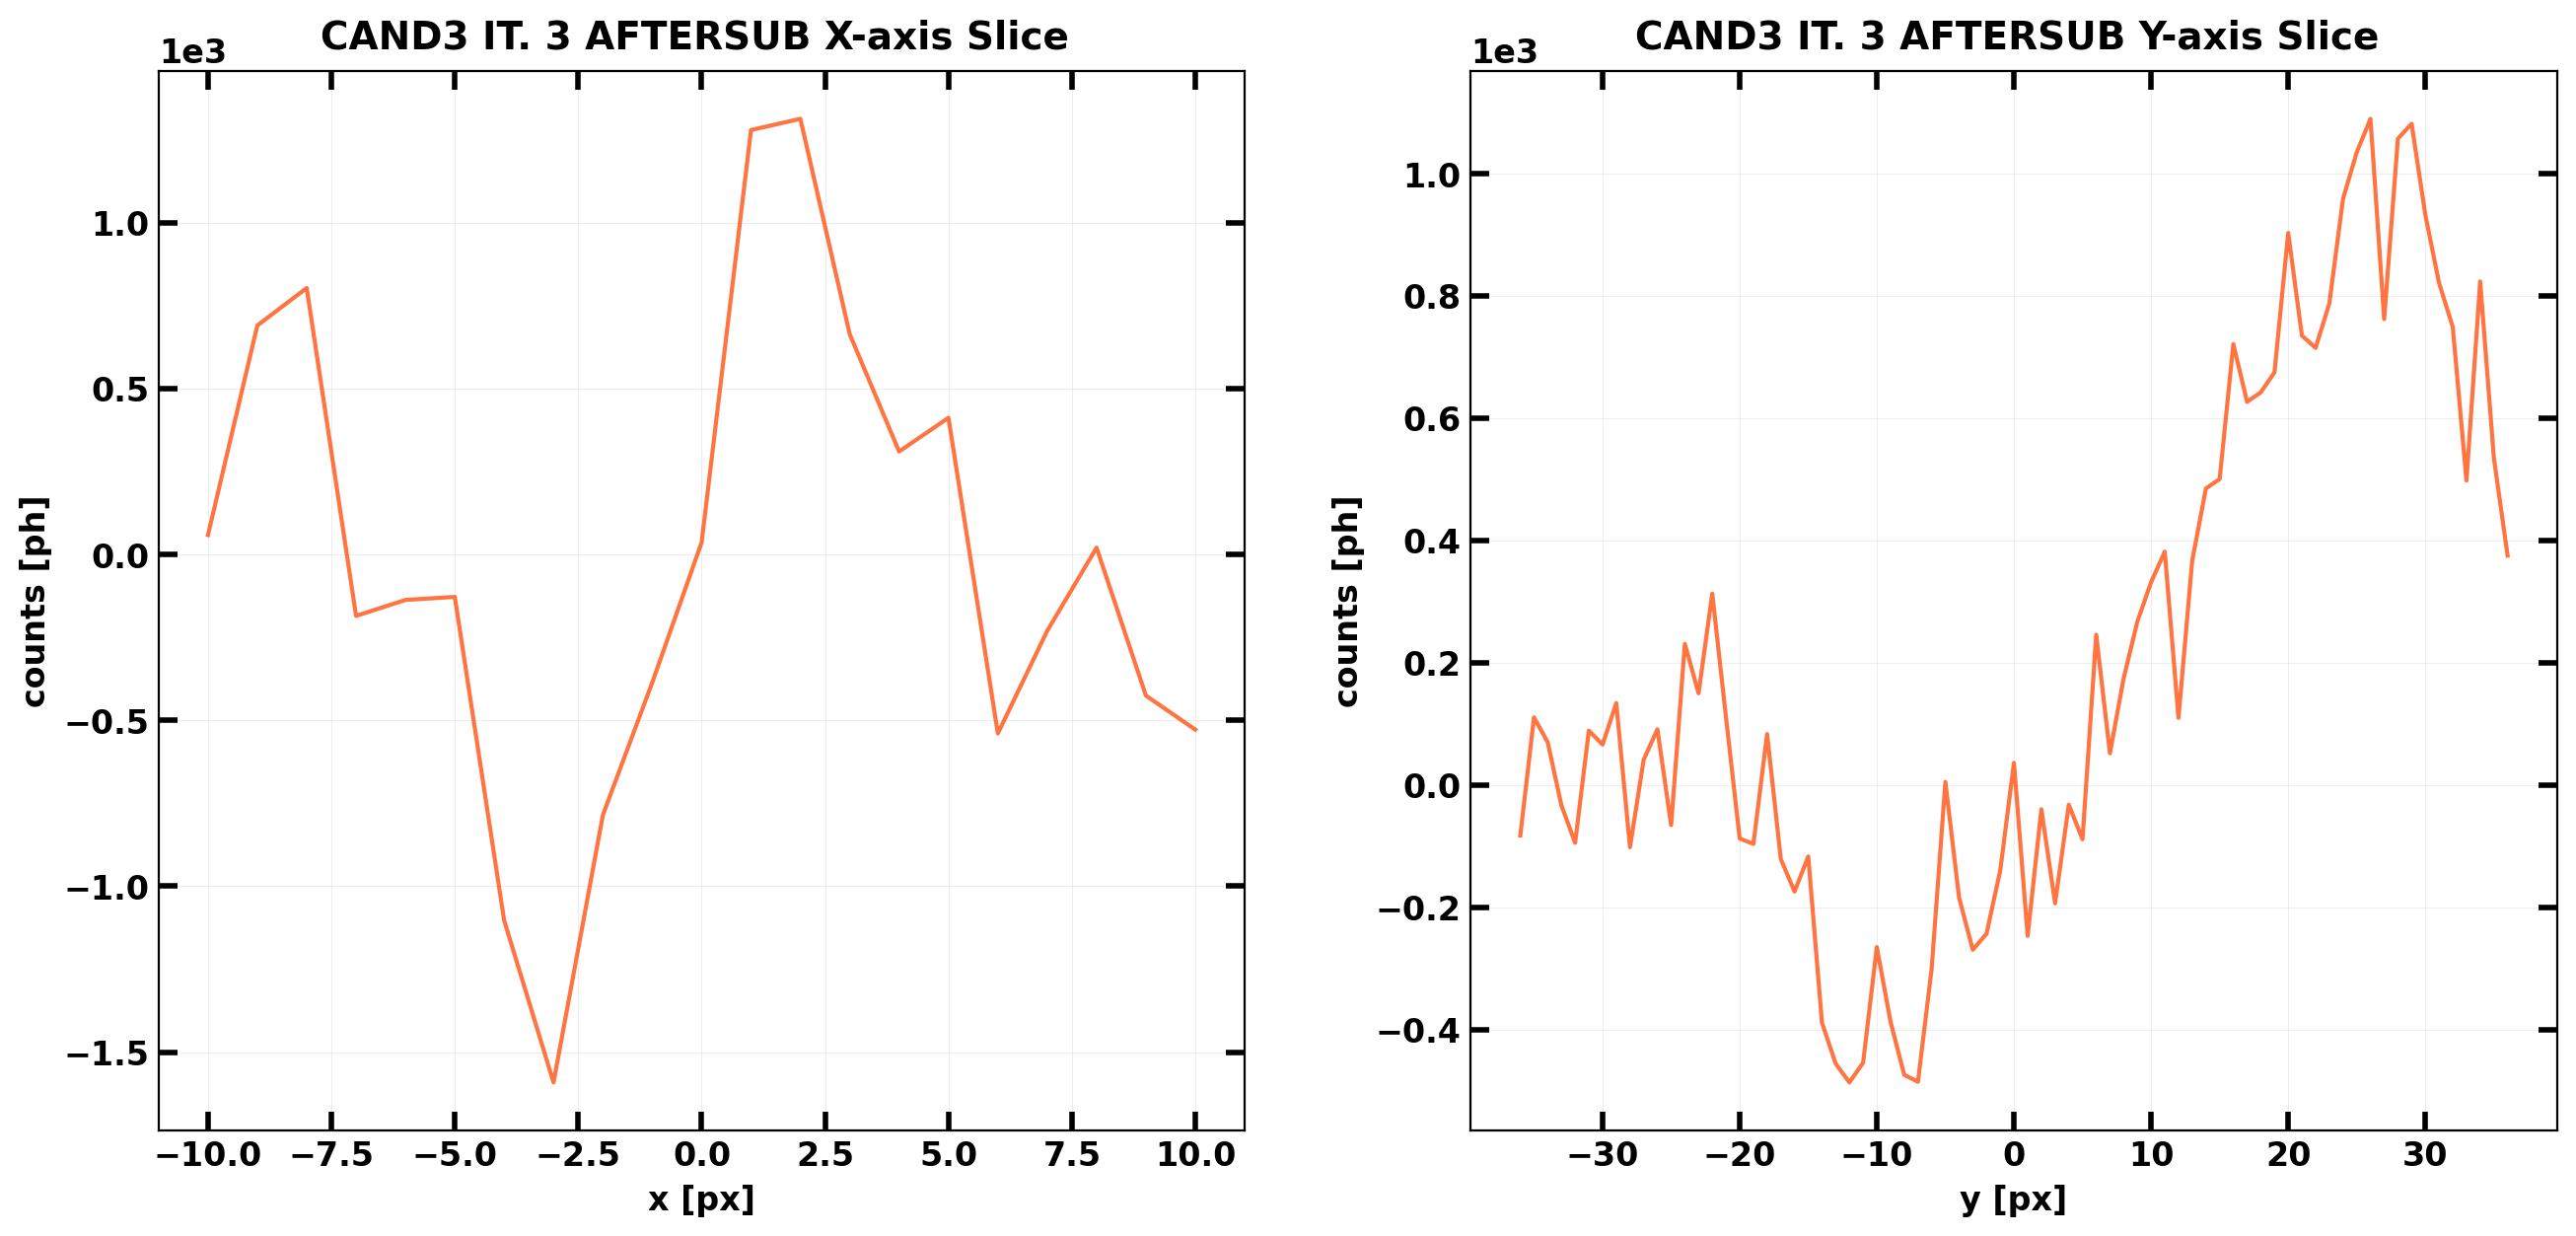

Candidate at iteration 4
  - Pos (y, x): (np.int64(644), np.int64(6288))
   - Sky-shifts (x, y): (105.44999999999999, 115.0)
   - Fluence: 4376.6563787777795
   - Significance: 5.072470636631439



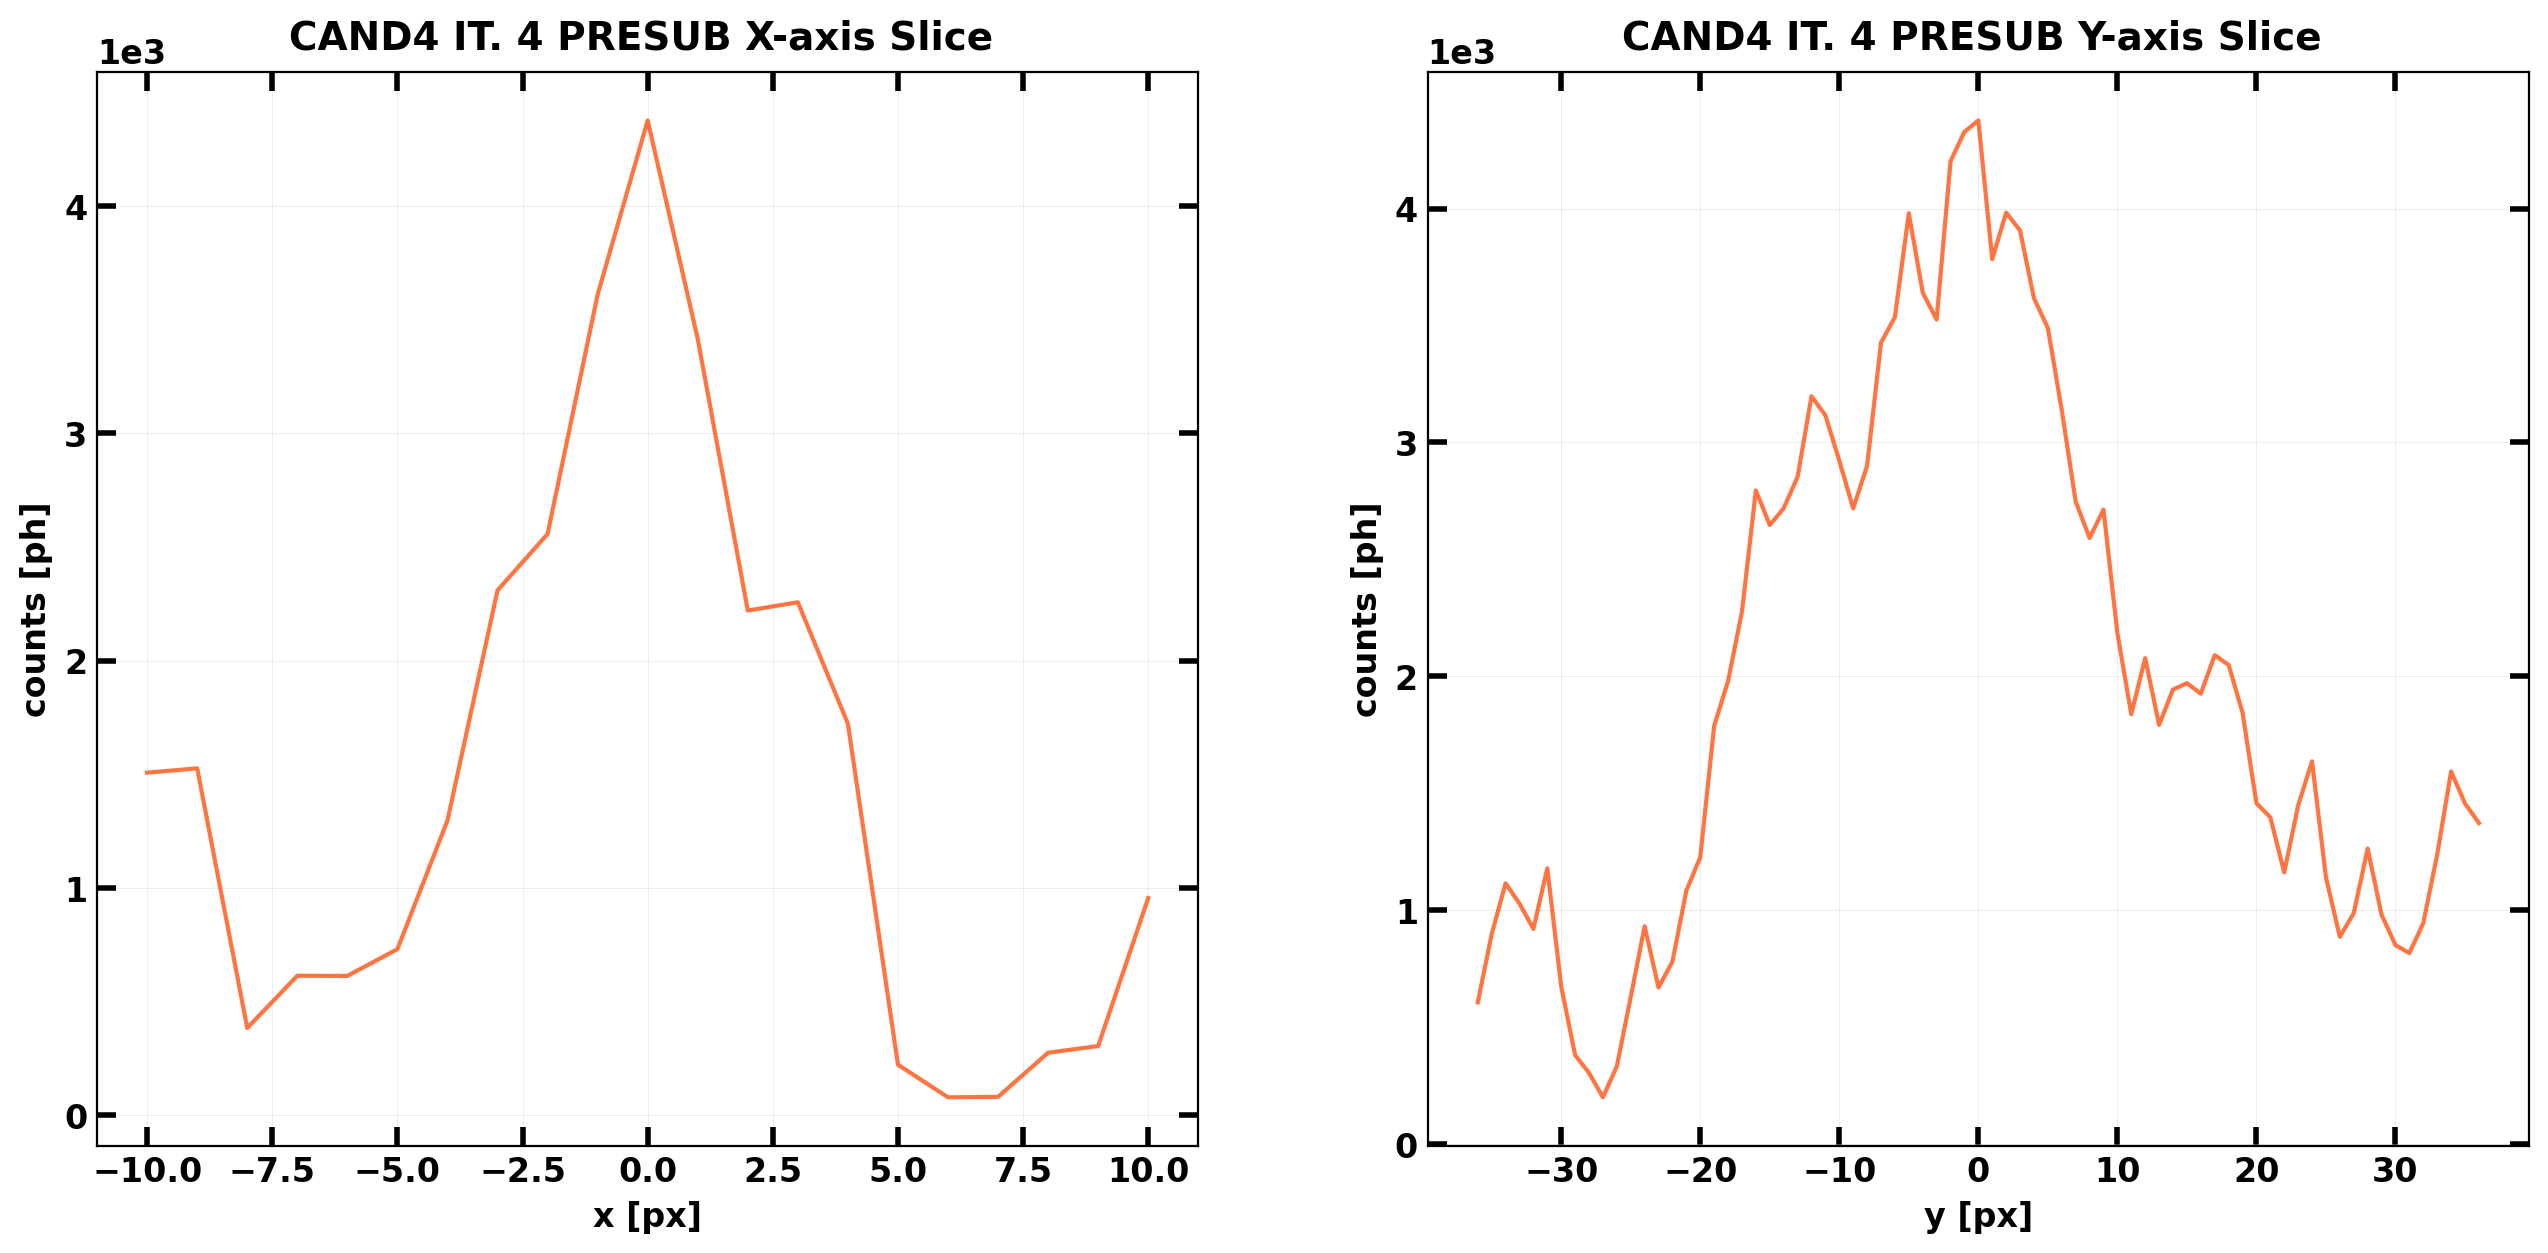

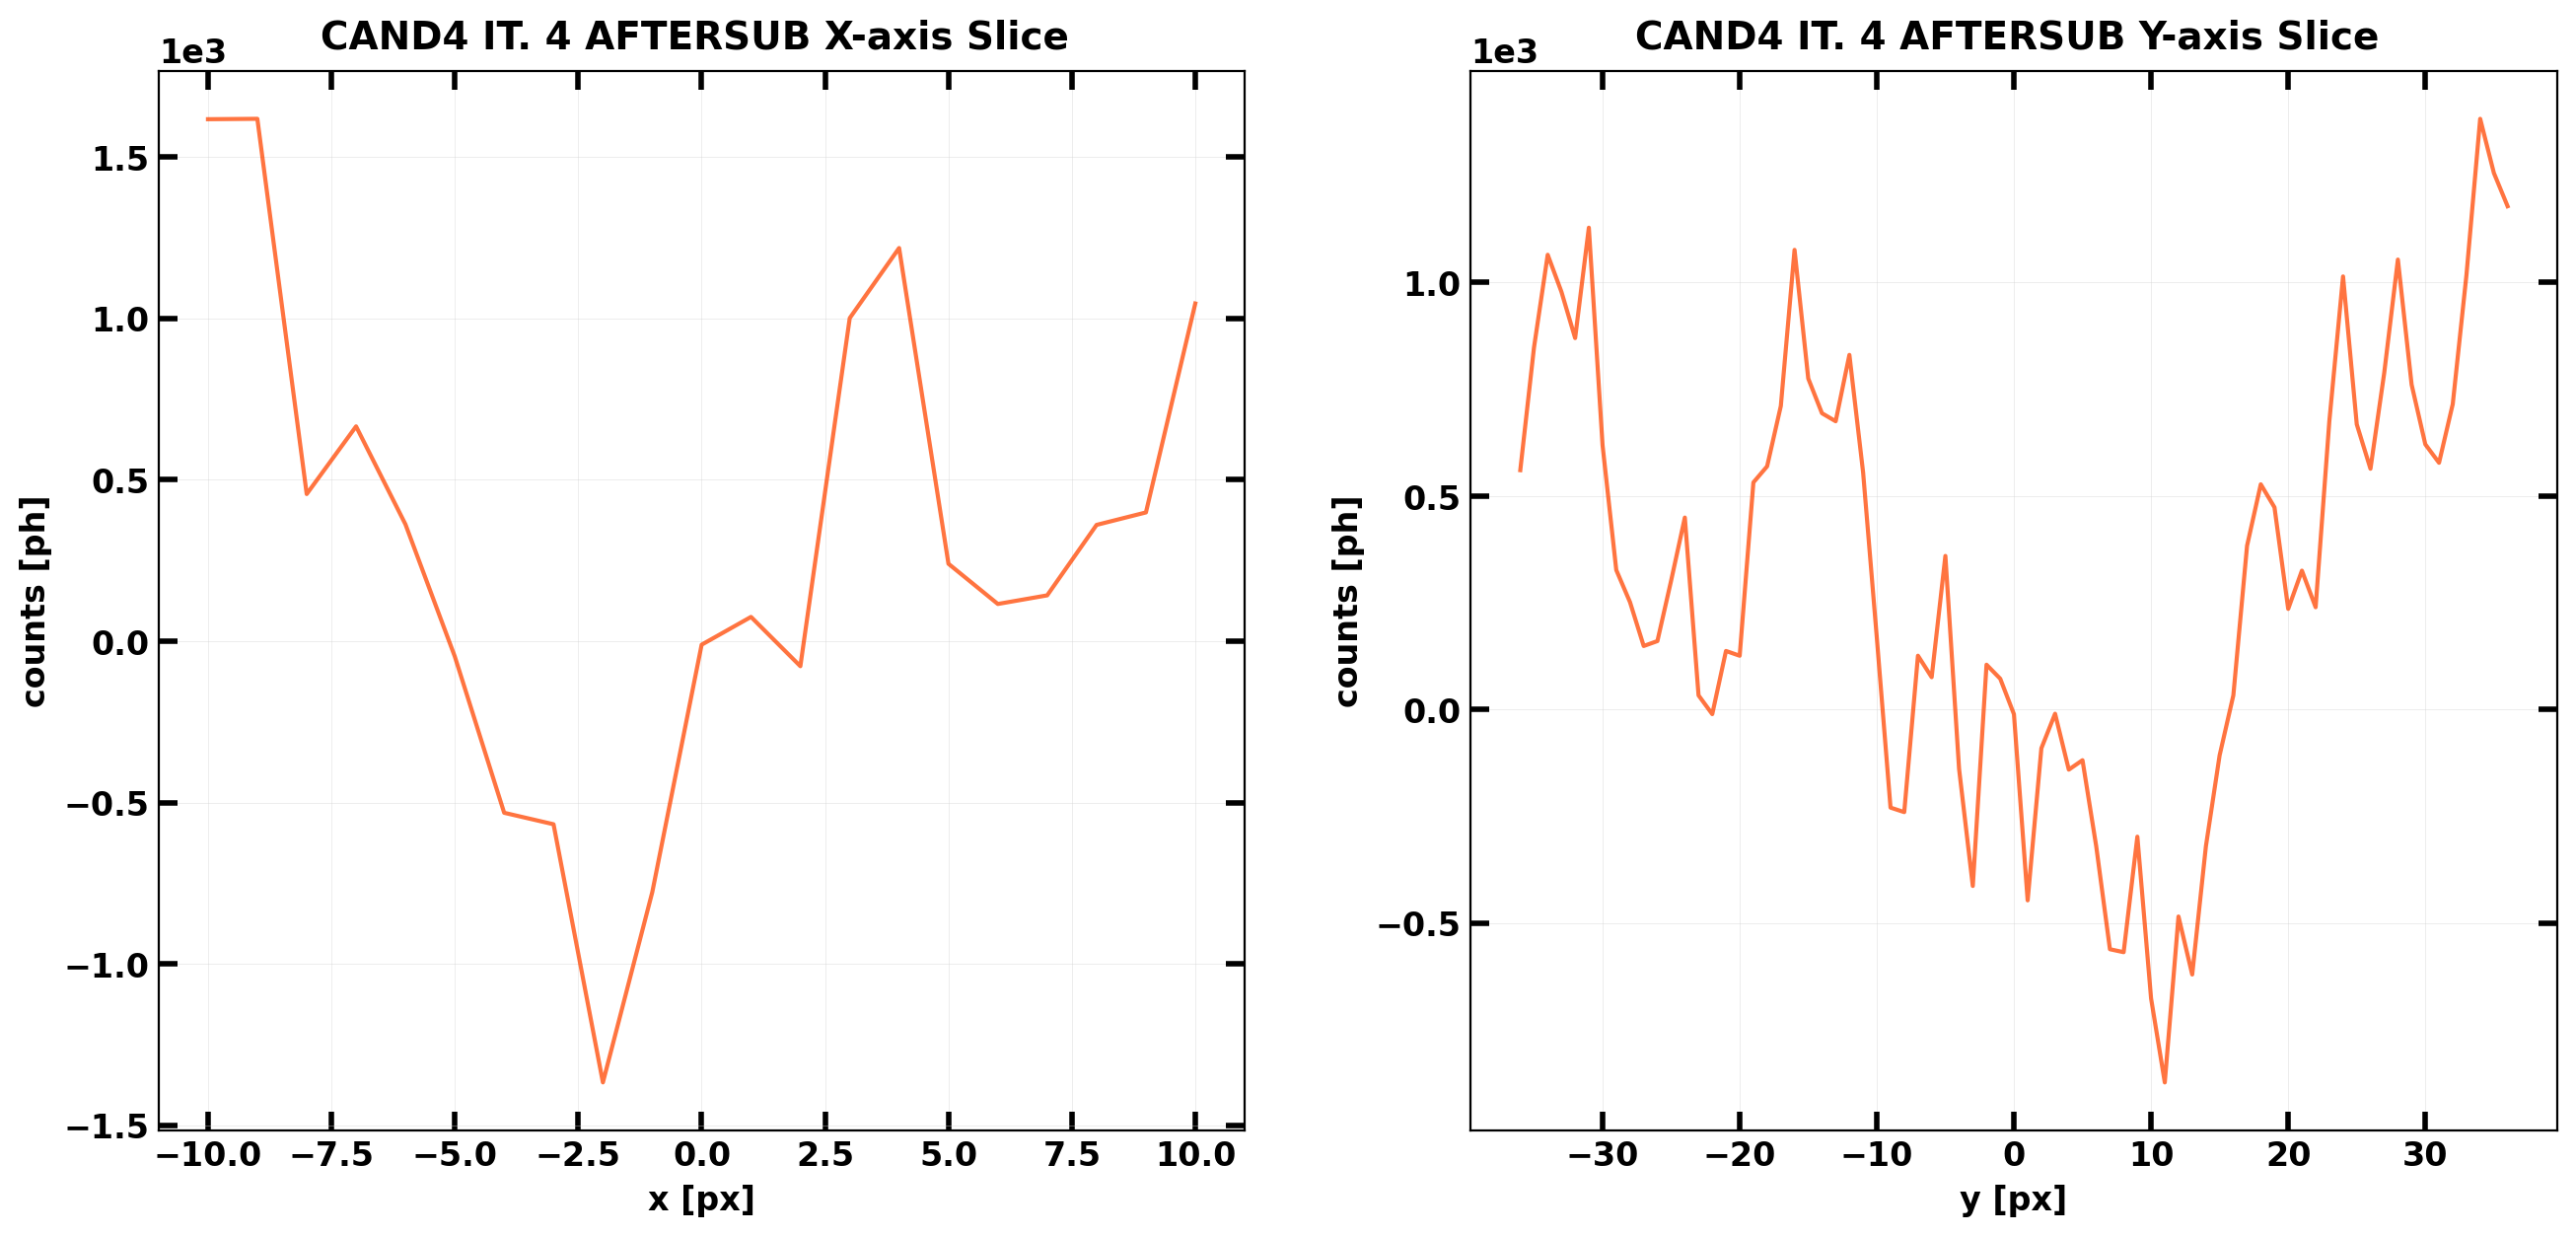

No more candidates...
# Comparing with Catalogue...
# Successful comparison!


(['scox1',
  Candidate(shift_x=43.89999999999998, shift_y=78.0, fluence=np.float64(19216.54118107108), snr=np.float64(14.157575651827035))],
 ['serx1',
  Candidate(shift_x=137.49999999999997, shift_y=-59.0, fluence=np.float64(7332.801493610783), snr=np.float64(7.021576796637399))],
 ['lemx-S1',
  Candidate(shift_x=30.249999999999986, shift_y=93.5, fluence=np.float64(6338.337340364907), snr=np.float64(5.018328278239811))],
 ['grs1915+105',
  Candidate(shift_x=174.95, shift_y=-108.0, fluence=np.float64(5458.892820986468), snr=np.float64(9.23793409809087))],
 ['lemx-S2',
  Candidate(shift_x=105.44999999999999, shift_y=115.0, fluence=np.float64(4376.6563787777795), snr=np.float64(5.072470636631439))])

In [6]:
cands = sequential_subtraction(res_sky, varmap, wfm, 20, 5.0, vignetting=VIGNETTING, psfy=PSFY)
cands_catalogue_comparison(cands, catalogueA, sdlA, wfm)

In [ ]:
def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)

ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
EXP = 0.5
tags = tuple(
    Tag(ID.upper(), y, x) for ID, y, x in zip(
        log_camA.log['ID'][:_UP_TO], log_camA.log['y'][:_UP_TO], log_camA.log['x'][:_UP_TO],
    )
)
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=sqrt_display(simul_sky_camA, EXP),
            title='Original Sky',
            cbarlabel='counts',
            tags=tags,
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 300,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_sky, EXP),
            title='Residual Sky',
            cbarlabel='counts',
            tags=tags,
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 300,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

In [ ]:
assert False

def source_profile_during_IROS(
    candidates: tuple[Candidate],
    true_sky: NDArray,
    variance: NDArray,
    lock_source: Tag,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
) -> None:
    """
    Displays the locked sources profile behaviour during the IROS reconstruction.
    """
    true_sky_ = true_sky.copy()
    lock_source_ = (lock_source,) if isinstance(lock_source, Tag) else lock_source

    for idx, (sx, sy, f, _) in enumerate(candidates):

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # locked sources profiles before subtraction (sky and significance)
        for tag in lock_source_:
            print(f'Fluence PRE-IROS: {true_sky_[tag.y, tag.x]}')
            #slices_plot(
            #    sky=true_sky_,
            #    pos=(tag.y, tag.x),
            #    crp=crp,
            #    source=f'{tag.ID} it. {idx}',
            #    ylabel='counts [ph]',
            #)
            #slices_plot(
            #    sky=sky_significance(true_sky_, variance),
            #    pos=(tag.y, tag.x),
            #    crp=crp,
            #    source=f'{tag.ID} it. {idx}',
            #    ylabel='significance',
            #    cameraID='SNR',
            #)
        
        # remove source from True sky
        true_sky_ -= modeled
    
    for tag in lock_source_:
        print(f'Fluence PRE-IROS: {true_sky_[tag.y, tag.x]}')
        #slices_plot(
        #    sky=true_sky_,
        #    pos=(tag.y, tag.x),
        #    crp=crp,
        #    source=f'{tag.ID} it. {idx + 1}',
        #    ylabel='counts [ph]',
        #)
        #slices_plot(
        #    sky=sky_significance(true_sky_, variance),
        #    pos=(tag.y, tag.x),
        #    crp=crp,
        #    source=f'{tag.ID} it. {idx + 1}',
        #    ylabel='significance',
        #    cameraID='SNR',
        #)


locked_source = Tag(f'{log_camA.log['ID'][0]}', log_camA.log['y'][0], log_camA.log['x'][0])

cropy, cropx = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)

source_profile_during_IROS(
    candidates=candidates,
    true_sky=simul_sky_camA,
    variance=varmap,
    lock_source=locked_source,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

Fluence PRE-IROS: 1040990
Fluence PRE-IROS: 17637
Fluence PRE-IROS: 17765
Fluence PRE-IROS: 17434
Fluence PRE-IROS: 18761
Fluence PRE-IROS: 18962
Fluence PRE-IROS: 18731
Fluence PRE-IROS: 18374
Fluence PRE-IROS: 18625
Fluence PRE-IROS: 18502
Fluence PRE-IROS: 18679
Fluence PRE-IROS: 18739
Fluence PRE-IROS: 18999
Fluence PRE-IROS: 19093
Fluence PRE-IROS: 19050
Fluence PRE-IROS: 19107
Fluence PRE-IROS: 19153
Fluence PRE-IROS: 19213
